# Optimising AdaBoost

First, I import the data and obtain an initial score. This section includes some feature engineering.
I then implement several CV techniques,
before exploring feature selection and engineering more thoroughly.
Next, I analyse and report the effect of using different feature subsets on model performance.
I then present and explain my modifications to AdaBoost from 00_adaboost_impl.ipynb.
Finally, I tune the model to optimise performance,
and deploy the final model on Kaggle for full data training to obtain a final score.

## Import the data and obtain an initial Kaggle score

In [4]:
# Local base directory
args['base_dir'] = 'kaggle/data/'
df_train = pd.read_csv(args['base_dir'] + 'train.csv')
df_train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0


health-insurance-cross-sell-prediction-data
contains health insurance policyholder data. Our objective is to
determine which current health insurance policyholders will also
want to take out a vehicle insurance policy.
First, we need to encode the data into a useable numerical format

In [930]:
def encode_data(df, drop_id=True, boost_labels=True):   
    df = df.copy()
    
    df['Vehicle_Age'] = df['Vehicle_Age'].astype('category')
    df = pd.get_dummies(df, columns=['Vehicle_Age'])
    
    df['Gender'] = df['Gender'].astype('category')
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

    df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
    
    if drop_id: df = df.drop('id', axis=1)

    return df.map(lambda x: 1 if x == True else (0 if x == False else x))

Response is the binary target:

In [5]:
def split_response(df):
    y = df['Response']
    X = df.drop(columns=['Response'])
    
    return X, y


def encode_labels(y):
    return y.map({0:-1, 1:1})

In [987]:
def sample_even(args, X, y):
    N_per_class = args['N'] // 2 # for 50/50 class split
        
    neg, pos = 0, 1
    
    # Sample N/2 from both classes
    X_sample_0 = X[y == neg].sample(n=N_per_class, replace=False, random_state=args['random_state'])
    X_sample_1 = X[y == pos].sample(n=N_per_class, replace=False, random_state=args['random_state'])
    
    # Undersample #-ve to match #+ve
    # X_sample_1 = X_train[y_train == pos]
    # N_per_class = len(X_sample_1)
    # X_sample_0 = X_train[y_train == neg].sample(n=N_per_class, replace=False, random_state=42)
    # N = N_per_class * 2
    
    X_sample = pd.concat([X_sample_0, X_sample_1])
    y_sample = y.loc[X_sample.index]
    
    # Put y into the last column of X and shuffle together
    combined_sample = pd.concat([X_sample, y_sample], axis=1)
    combined_sample = combined_sample.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Resplit
    X_sample = combined_sample.iloc[:, :-1]
    y_sample = combined_sample.iloc[:, -1]
    
    return X_sample, y_sample


def split_data(args, X, y, ratio):
    split_idx = int(np.floor(ratio * len(X)))
    X_train, y_train = X.iloc[:split_idx], y[:split_idx]
    X_test, y_test = X[split_idx:], y[split_idx:]
    X_train, y_train = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
    X_test, y_test = X_test.reset_index(drop=True), y_test.reset_index(drop=True)
    return X_train, y_train, X_test, y_test

The initial Kaggle score was obtained used the unmodified AdaBoost algorithm using 
20 rounds on the
full dataset with the negative class downsampled to match the positive class.
Below I implement the unmodified AdaBoost algorithm on a balanced sample of 100000
instances.

In [37]:
X, y = split_response(df_train)

In [988]:
args['N'] = 100000
X_sample, y_sample = sample_even(args, X, y)
X_encode = encode_data(X_sample)
y_encode = encode_labels(y_sample)
X_encode.head()

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age_1-2 Year,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Gender_Male
0,54,1,28.0,0,1,48105.0,26.0,93,1,0,0,0
1,39,1,47.0,0,1,25230.0,16.0,144,1,0,0,1
2,28,1,41.0,1,0,33917.0,152.0,132,0,1,0,1
3,51,1,0.0,0,1,2630.0,8.0,226,1,0,0,1
4,70,1,28.0,0,1,51154.0,26.0,170,0,0,1,1


In [989]:
y_encode.value_counts()

Response
 1    50000
-1    50000
Name: count, dtype: int64

In [990]:
X_train, y_train, X_test, y_test = split_data(args, X_encode, y_encode, 0.7)
X_val, y_val, X_test, y_test = split_data(args, X_test, y_test, 0.5)

print(X_train.shape, X_val.shape, X_test.shape)

(70000, 12) (15000, 12) (15000, 12)


In [953]:
args['silent'] = False
args['T'] = 20
adaboost_20, train_err_20, val_err_20 = train_adaboost(args, X_train, y_train, X_val, y_val)

BOOSTING ROUND: 1
WEIGHTED ERROR OF DECISION BOUNDARY: 0.2266 --->> FEATURE, THRESHOLD, DIRECTION: (4, np.float64(0.5), np.float64(1.0))
CURRENT ERROR: 0.2266
CURRENT VAL ERROR: 0.22393333333333335


BOOSTING ROUND: 2
WEIGHTED ERROR OF DECISION BOUNDARY: 0.33654647791820447 --->> FEATURE, THRESHOLD, DIRECTION: (6, np.float64(161.38), np.float64(1.0))
CURRENT ERROR: 0.2266
CURRENT VAL ERROR: 0.22393333333333335


BOOSTING ROUND: 3
WEIGHTED ERROR OF DECISION BOUNDARY: 0.36066759886602345 --->> FEATURE, THRESHOLD, DIRECTION: (3, np.float64(0.5), np.float64(-1.0))
CURRENT ERROR: 0.2131142857142857
CURRENT VAL ERROR: 0.2112


BOOSTING ROUND: 4
WEIGHTED ERROR OF DECISION BOUNDARY: 0.38977852319228956 --->> FEATURE, THRESHOLD, DIRECTION: (5, np.float64(100036.59999999999), np.float64(1.0))
CURRENT ERROR: 0.2131142857142857
CURRENT VAL ERROR: 0.21113333333333334


BOOSTING ROUND: 5
WEIGHTED ERROR OF DECISION BOUNDARY: 0.40381798723428214 --->> FEATURE, THRESHOLD, DIRECTION: (0, np.float64(28.1

In [955]:
get_metrics(adaboost_20, X_test, y_test)

{'precision': 0.6995,
 'recall': 0.9802,
 'f1': 0.8164,
 'accuracy': 0.7816,
 'mcc': 0.6151,
 'kappa': 0.5648,
 'lift': 1.4121,
 'roc_auc': 0.841}

Above shows the initial AdaBoost with all the features (metrics may be inflated due to balancing the test set).
The full Kaggle dataset was balanced by undersampling the negative samples, using the features 
above, it achieved an initial score of 0.84532.

For each boosting round, AdaBoost iterates through each feature when searching for the optimal threshold. 
Therefore, splitting Vehicle_Age into three features is
inefficient as this information can be provided in one feature by mapping '< 1 Year' to 0, '1-2 Year' to 1, and '> 2 Years' to 2.

In [1012]:
X_train.filter(regex='Vehicle_Age').head()

,Vehicle_Age_1-2 Year,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,0,0,1


In [6]:
def encode_data(df, drop_id=True):       
    df = df.copy()
    df['Vehicle_Age'] = df['Vehicle_Age'].map({
        "< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2})
    
    df['Gender'] = df['Gender'].astype('category')
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

    df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0})
    
    if drop_id: df = df.drop('id', axis=1)

    return df.map(lambda x: 1 if x == True else (0 if x == False else x))

In [ ]:
X_encode = encode_data(X_sample)
X_encode.head()

In [1015]:
X_train, y_train, X_test, y_test = split_data(args, X_encode, y_encode, 0.7)
X_val, y_val, X_test, y_test = split_data(args, X_test, y_test, 0.5)

## Cross-validation for robustness and to avoid overfitting

I implement early stopping (tolerance + patience) on a validation set to limit overfitting.
I then apply k-fold + stratified k-fold CV. The latter captures the original data imbalance
which improves comparisons of impact of tuning and data balancing.

#### Early Stopping

Adding weak classifiers to AdaBoost often improves performance by increasing margins, but too many can overfit by fitting training noise instead of the proper decision boundary.
Early stopping is a regularisation technique that aims to prevent this
by partitioning a validation set and monitoring a metric at each step,
here the target metric, ROC AUC.
Throughout training, exponential loss for the training set decreases whereas validation ROC AUC increases. However validation error and ROC AUC may eventually degrade. Training stops at this point, reverting to the model with the best validation ROC AUC.
Tolerance determines the score drop needed, and patience the rounds to wait without improvement, before cessation.

In [29]:
class EarlyStopping:
    
    def __init__(self, args, metric='roc_auc'):
        self.tolerance = args.get('es_tolerance', 0)
        self.patience = args.get('es_patience', 0)
        self.silent = args.get('silent', False)
        self.threshold = args.get('threshold', 0.5)
        self.metric = metric
        self.best_score = 0
        self.best_classifier = None
        self.best_train_err = float('inf')
        self.best_val_err = float('inf')
        self.rounds_without_improvement = 0

    def check(self, val_pred, label_val, classifier, train_err, val_err):
        val_prob = calculate_probabilities(val_pred).probabilities
        score = calculate_metric(val_prob, label_val, metric=self.metric, threshold=self.threshold)
        if not self.silent: print(f"CURRENT VAL {self.metric}: {score}")
        
        if score > self.best_score:
            self.best_score = score
            self.best_classifier = classifier.copy()
            self.best_train_err = train_err.copy()
            self.best_val_err = val_err.copy()
        elif score < self.best_score - self.tolerance:  
            self.rounds_without_improvement += 1
            if not self.silent:
                print(f"Validation ROC/AUC has not improved considering tolerance in {self.rounds_without_improvement} round(s).")
            if self.rounds_without_improvement > self.patience:
                if not self.silent: print("Reached early stopping patience.")
                return 'stop'
        return 'continue'

    def get_best(self):
        best_classifier = self.best_classifier.drop(
            self.best_classifier.index[self.best_classifier['alpha'] == 0].tolist())
        best_train_err = self.best_train_err[~np.isnan(self.best_train_err)]
        best_val_err = self.best_val_err[~np.isnan(self.best_val_err)]
        
        return best_classifier, best_train_err, best_val_err

In [997]:
def train_adaboost(args, X, label, X_val, label_val):
    silent = args.get('silent', False)
    early_stopping = args.get('early_stopping', False)

    T = args['T']
    X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    label = label if isinstance(label, pd.Series) else pd.Series(label)
    N, n_feat = X.shape
    N_val = len(X_val)

    visualiser = Visualiser(N, N_val, T)
    es = EarlyStopping(args)
    
    h, alpha, err, weight = reset_param(args, N)
    
    train_err = np.array([None] * (T+1), dtype=float)
    train_err[0] = 1.0
    val_err = np.array([None] * (T+1), dtype=float)
    val_err[0] = 1.0
     
    classification_sum = np.zeros(N)
    pos_votes = np.zeros(N, dtype=np.float64)
    neg_votes = np.zeros(N, dtype=np.float64)

    classification_sum_val = np.zeros(N_val)
    pos_votes_val = np.zeros(N_val, dtype=np.float64)
    neg_votes_val = np.zeros(N_val, dtype=np.float64)

    for t in range(T):
        for feature in range(n_feat):
            threshold, sign, weighted_error = calculate_decision_stump(
                args, X.iloc[:, feature], weight, label)
     
            if weighted_error < err[t] :
                err[t] = weighted_error
                h[t] = [threshold, feature, sign]

        best_thresh, best_feature, best_sign = h[t][0], int(h[t][1]), h[t][2]
        ht = np.sign(X.iloc[:, int(best_feature)] - best_thresh) * best_sign
        ht_val = np.sign(X_val.iloc[:, int(best_feature)] - best_thresh) * best_sign

        alpha[t] = calculate_alpha(args, err[t])

        # Calculate total errors
        classification_sum += alpha[t] * ht
        classification_sum_val += alpha[t] * ht_val
        final_label = np.sign(classification_sum)
        final_label_val = np.sign(classification_sum_val)     
        train_err[t+1] = np.sum(np.float64(final_label != np.array(label))) / N
        val_err[t+1] = np.sum(np.float64(final_label_val != np.array(label_val))) / N_val
        
        pos_votes += np.where(ht == 1, alpha[t], 0)
        neg_votes += np.where(ht == -1, alpha[t], 0)
        sum_alpha = pos_votes - neg_votes
        train_pred = pd.DataFrame({
            'classifications': final_label,
            'pos_votes': pos_votes,
            'neg_votes': neg_votes,
            'sum_alpha': sum_alpha
        })
      
        weight = update_weights(args, weight, alpha[t], ht, label)
        weight = normalise_weights(weight)
        
        if not silent:   
            visualiser.print_info_no_compute(t, err[t], train_err[t+1], val_err[t+1])
            
        if early_stopping:        
            pos_votes_val += np.where(ht_val == 1, alpha[t], 0)
            neg_votes_val += np.where(ht_val == -1, alpha[t], 0)
            sum_alpha_val = pos_votes_val - neg_votes_val
            val_pred = pd.DataFrame({
                'classifications': final_label_val,
                'pos_votes': pos_votes_val,
                'neg_votes': neg_votes_val,
                'sum_alpha': sum_alpha_val
            })

            if es.check(val_pred, label_val, classifier, train_err, val_err) == 'stop':
                best_classifier, best_train_err, best_val_err = es.get_best()
                return best_classifier, best_train_err, best_val_err

        
        if not silent: print('\n')

    classifier = pd.DataFrame(h, columns=['threshold', 'feature', 'direction'])
    classifier['alpha'] = alpha
                    
    return classifier, train_err, val_err

##### Early stopping demonstration

A model with
zero patience and zero tolerance.

In [972]:
args['T'] = 50
args['silent'] = False
args['early_stopping'] = True
args['es_tolerance'] = 0
args['es_patience'] = 0
adaboost_ESdemo, train_err_ESdemo, val_err_ESdemo = train_adaboost(
    args, X_train, y_train, X_val, y_val)
get_metrics(adaboost_ESdemo, X_test, y_test)

BOOSTING ROUND: 1
WEIGHTED ERROR OF DECISION BOUNDARY: 0.2266
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239
CURRENT VAL roc_auc: 0.5580331871516289


BOOSTING ROUND: 2
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3365
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239
CURRENT VAL roc_auc: 0.7752420909993734


BOOSTING ROUND: 3
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3607
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2112
CURRENT VAL roc_auc: 0.7919136723528384


BOOSTING ROUND: 4
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3898
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111
CURRENT VAL roc_auc: 0.792039295588112


BOOSTING ROUND: 5
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4038
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111
CURRENT VAL roc_auc: 0.8213371856369664


BOOSTING ROUND: 6
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4413
CURRENT TRAIN ERROR: 0.2132
CURRENT VAL ERROR: 0.2112
CURRENT VAL roc_auc: 0.8222687712763798


BOOSTING ROUND: 7
WEIGHTED ERROR OF DECISION BOUNDARY

{'precision': 0.6995,
 'recall': 0.9802,
 'f1': 0.8164,
 'accuracy': 0.7816,
 'mcc': 0.6151,
 'kappa': 0.5648,
 'lift': 1.4121,
 'roc_auc': 0.8176}

Tolerence of 0.001.

In [973]:
args['es_tolerance'] = 0.001
args['es_patience'] = 0
adaboost_ESdemo, train_err_ESdemo, val_err_ESdemo = train_adaboost(
    args, X_train, y_train, X_val, y_val)
get_metrics(adaboost_ESdemo, X_test, y_test)

BOOSTING ROUND: 1
WEIGHTED ERROR OF DECISION BOUNDARY: 0.2266
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239
CURRENT VAL roc_auc: 0.5580331871516289


BOOSTING ROUND: 2
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3365
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239
CURRENT VAL roc_auc: 0.7752420909993734


BOOSTING ROUND: 3
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3607
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2112
CURRENT VAL roc_auc: 0.7919136723528384


BOOSTING ROUND: 4
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3898
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111
CURRENT VAL roc_auc: 0.792039295588112


BOOSTING ROUND: 5
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4038
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111
CURRENT VAL roc_auc: 0.8213371856369664


BOOSTING ROUND: 6
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4413
CURRENT TRAIN ERROR: 0.2132
CURRENT VAL ERROR: 0.2112
CURRENT VAL roc_auc: 0.8222687712763798


BOOSTING ROUND: 7
WEIGHTED ERROR OF DECISION BOUNDARY

{'precision': 0.6995,
 'recall': 0.9801,
 'f1': 0.8164,
 'accuracy': 0.7816,
 'mcc': 0.615,
 'kappa': 0.5648,
 'lift': 1.4122,
 'roc_auc': 0.8378}

And patience 10:

In [47]:
args['es_tolerance'] = 0.001
args['es_patience'] = 10
adaboost_ESdemo, train_err_ESdemo, val_err_ESdemo = train_adaboost(
    args, X_train, y_train, X_val, y_val)
get_metrics(adaboost_ESdemo, X_test, y_test)

BOOSTING ROUND: 1
WEIGHTED ERROR OF DECISION BOUNDARY: 0.2266
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239


BOOSTING ROUND: 2
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3365
CURRENT TRAIN ERROR: 0.2266
CURRENT VAL ERROR: 0.2239


BOOSTING ROUND: 3
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3607
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2112


BOOSTING ROUND: 4
WEIGHTED ERROR OF DECISION BOUNDARY: 0.3898
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111


BOOSTING ROUND: 5
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4038
CURRENT TRAIN ERROR: 0.2131
CURRENT VAL ERROR: 0.2111


BOOSTING ROUND: 6
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4413
CURRENT TRAIN ERROR: 0.2132
CURRENT VAL ERROR: 0.2112


BOOSTING ROUND: 7
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4278
CURRENT TRAIN ERROR: 0.2130
CURRENT VAL ERROR: 0.2113


BOOSTING ROUND: 8
WEIGHTED ERROR OF DECISION BOUNDARY: 0.4317
CURRENT TRAIN ERROR: 0.2130
CURRENT VAL ERROR: 0.2111


BOOSTING ROUND: 9
WEIGHTED ERROR OF DECISION BOUNDARY: 0

/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


{'precision': 0.7116,
 'recall': 0.9556,
 'f1': 0.8157,
 'accuracy': 0.7861,
 'mcc': 0.6096,
 'kappa': 0.5736,
 'lift': 1.4365,
 'roc_auc': 0.8466}

Using tolerance 0.001 and patience 10, the model ran for 30 rounds.

#### K-Fold Cross Validation

In k-fold cross-validation, the data are divided into k subsets. The model uses k-1 for training and the remaining fold for validation. This repeats k times, with each fold used for validation once. This function generates the indices for the k folds.

In [48]:
def get_fold_indices(X, y, k, stratified=False, adaboost_labels=True):
    # Assumes shuffled data
    X_size = len(X)
    indices = np.arange(X_size)
    folds = []
    neg_label = -1 if adaboost_labels else 0
    if stratified:
        neg = np.where(y == neg_label)[0]
        pos = np.where(y == 1)[0]

        N_pos, N_neg = len(pos), len(neg)

        N_neg_per_fold = N_neg // k
        N_pos_per_fold = N_pos // k

        for i in range(k):
            train, val = [], []
            val_pos_start, val_pos_end = i * N_pos_per_fold, (i + 1) * N_pos_per_fold
            val_neg_start, val_neg_end = i * N_neg_per_fold, (i + 1) * N_neg_per_fold
            val_pos, val_neg = pos[val_pos_start:val_pos_end], neg[val_neg_start:val_neg_end]
            val.extend(val_pos)
            val.extend(val_neg)
            val = np.array(val)
            
            train_neg_mask = np.isin(neg, val_neg, invert=True)
            train_pos_mask = np.isin(pos, val_pos, invert=True)
            train = np.concatenate([neg[train_neg_mask], pos[train_pos_mask]])

            folds.append((train,val))
    else:
        val_size = X_size // k
        
        for i in range(k):
            val_start = i * val_size
            val_end = X_size if i+1 == k else val_start + val_size  # Handles last fold when ~ k | X_size
            val = indices[val_start:val_end]
            train = np.concatenate((indices[:val_start], indices[val_end:]))
            folds.append((train, val))

    return folds

In [49]:
def preprocess_train(args, X_train, y_train):
    # This function is to be modified
    return X_train, y_train

In [50]:
import concurrent.futures
import time

def train_model_get_metrics(args, X_train, y_train, X_val, y_val):
    tree = args.get('decision_tree', False)
    
    classifier, train_err, val_err = train_adaboost(args, X_train, y_train, X_val, y_val)
    val_metric = get_metrics(classifier, X_val, y_val, tree=tree)
    
    return classifier, train_err, val_err, val_metric

def preprocess_train_metrics(args, X, label, train_indices, val_indices):
    local_args = args.copy()
    local_args['silent'] = True
    
    X_train, y_train = [df.iloc[train_indices].reset_index(drop=True) for df in (X, label)]
    X_val, y_val = [df.iloc[val_indices].reset_index(drop=True) for df in (X, label)]

    X_train, y_train = preprocess_train(args, X_train, y_train)

    classifier, train_err, val_err, val_metric = train_model_get_metrics(local_args, X_train, y_train, X_val, y_val)
    
    return classifier, train_err, val_err, val_metric


def train_adaboost_k_fold(args, X, label, k=5, stratified=False):
    silent = args.get('silent', False)
        
    start_time = time.time()

    fold_indices = get_fold_indices(X, label, k, stratified)

    classifiers, train_errs, val_errs, val_metrics = [], [], [], []
    futures = []
    with concurrent.futures.ProcessPoolExecutor() as executor:
        for train, val in fold_indices:
            futures.append(executor.submit(preprocess_train_metrics, args, X, label, train, val))    

        for future in concurrent.futures.as_completed(futures):
            classifier, train_err, val_err, val_metric = future.result()
            classifiers.append(classifier)
            train_errs.append(train_err)
            val_errs.append(val_err)
            val_metrics.append(val_metric)
            if not silent: print(f"Fold {len(classifiers)} complete.")
    
    elapsed_time = time.time() - start_time
    if not silent: print(f"Completed cross-validation in {elapsed_time} seconds.")
    
    return classifiers, train_errs, val_errs, val_metrics, elapsed_time

In [51]:
def avg_metrics(metric_dicts):
    n_classifiers = len(metric_dicts)
    
    sums = {}
    
    for metric_dict in metric_dicts:
        for k, v in metric_dict.items():
            if k not in sums: sums[k] = v
            else: sums[k] += v
    
    return {k: v / n_classifiers for k, v in sums.items()}

In [1037]:
args['T'] = 50
args['early_stopping'] = False
args['silent'] = False
adaboosts_50, train_errs_50, val_errs_50, val_metrics_50, _ = train_adaboost_k_fold(args, X_train, y_train)
print(f"Averages - training error: {np.mean(train_errs_50)}, validation error: {np.mean(val_errs_50)}, validation ROC/AUC: {avg_metrics(val_metrics_50)['roc_auc']}")

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 474.29469561576843 seconds.
Averages - training error: 0.22523697478991597, validation error: 0.2255591036414566, validation ROC/AUC: 0.85178


#### Stratified K-Fold Cross-Validation 

So far a balanced sample has been used. However standard k-fold can distort class distribution since one or more folds may contain few minority samples, resulting in misleading metrics versus full dataset performance. Furtheremore the validation sets are balanced and so may misrepresent full test performance.
Stratified k-fold preserves class proportions in each fold and so more reliably estimates performance on unseen data. This is implemented above. I take a stratified sample to capture
the original data imbalance.

In [52]:
# Before performing k-fold, generate a sample with the same imbalance as the full dataset
def sample_stratified(args, X, y):
    N = args['N']

    neg = np.where(y == 0)[0]
    pos = np.where(y == 1)[0]

    N_pos, N_neg = len(pos), len(neg)
    
    pos_ratio = N_pos / (N_pos + N_neg)
    N_pos_sample = int(N * pos_ratio)
    N_neg_sample = N - N_pos_sample

    neg_indices_sample = np.random.choice(neg, size=N_neg_sample, replace=False)
    pos_indices_sample = np.random.choice(pos, size=N_pos_sample, replace=False)
    sample_indices = np.concatenate((neg_indices_sample, pos_indices_sample))

    np.random.shuffle(sample_indices)

    return X.iloc[sample_indices], y.iloc[sample_indices]

In [53]:
args['N'] = 100000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
print('Full training data\n--\n', y.shape, y.value_counts(normalize=True))
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts(normalize=True))

Full training data
--
 (11504798,) Response
0    0.877003
1    0.122997
Name: proportion, dtype: float64

Sampled data
--
 (100000,) Response
-1    0.87701
 1    0.12299
Name: proportion, dtype: float64


In [1039]:
args['T'] = 50
args['early_stopping'] = False
args['silent'] = False
adaboosts_50_strat, train_errs_50_strat, val_errs_50_strat, metrics_50_strat, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
print(f"Averages - training error: {np.mean(train_errs_50_strat)}, validation error: {np.mean(val_errs_50_strat)}, validation ROC/AUC: {avg_metrics(metrics_50_strat)['roc_auc']}")

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 575.048130273819 seconds.
Averages - training error: 0.14108882462498631, validation error: 0.1412815738826157, validation ROC/AUC: 0.8506


In [1040]:
avg_metrics(metrics_50_strat)

{'precision': 0.43018,
 'recall': 0.01588,
 'f1': 0.030440000000000002,
 'accuracy': 0.8762799999999998,
 'mcc': 0.061380000000000004,
 'kappa': 0.021719999999999996,
 'lift': 3.49862,
 'roc_auc': 0.8506}

The above uses an unbalanced validation set closer to the actual test set.

## Data balancing

Class imbalance can bias weak learners toward the majority class harming performance on the minority class. Balancing increases minority representation to improve decision stump splits and therefore minority class and overall learning.
Synthetic Minority Over-sampling Technique (SMOTE) is a popular oversampling method that generates synthetic minority samples via the k-nearest neighbours in the feature
space for a given sample and interpolating between it and a neighbour, adding variability. SMOTE is often perfered over random oversampling as it provides new, informative samples.

To estimate performance on the imbalanced test set with oversampled data, I do the following:
- Create stratified k-folds folds with the same imbalance as the full dataset
- Before training, balance the k-1 training folds (via oversampling, undersampling, or hybrid) but leave the validation fold unbalanced

In [65]:
df_test = pd.read_csv(args['base_dir'] + 'test.csv') 
X_test_full = encode_data(df_test)
X_test_full.shape

(7669866, 10)

In [1041]:
# Classify the test data to confirm that it is imbalanced.
test_pred_strat = classify_and_sum_votes(X_test_full, adaboosts_50_strat[0]).classifications
test_pred_strat.value_counts(normalize=True)

classifications
-1    0.993462
 1    0.006538
Name: proportion, dtype: float64

This model overwhelmingly classified the test data as negative.
Since the actual test imbalance is probably less severe (considering the training
data and problem context), this reflects an issue caused by seeing too few
positive samples during training. 

In [1042]:
# Informally compare with model trained on balanced data
test_pred = classify_and_sum_votes(X_test, adaboosts_50[0]).classifications
test_pred.value_counts(normalize=True)

classifications
 1    0.643467
-1    0.356533
Name: proportion, dtype: float64

This model, trained on balanced data,
predicted a far greater proportion of the test data
as positive while retaining an imbalance.
Assuming the distribution of the test set is closer to this, we can note:

1. The test data is imbalanced,
2. Training on balanced data improves model performance,
  
making this dataset a good candidate for oversampling. But first, undersampling:

In [54]:
def undersample_neg(args, X, y, ratio=0.5, adaboost_labels=True):
    neg, pos = -1 if adaboost_labels else 0, 1
    
    neg_indices = y[y == neg].index
    pos_indices = y[y == pos].index
    
    N_pos = len(pos_indices)
    N_neg = int(N_pos / ratio - N_pos)

    # Undersample
    neg_sample_indices = neg_indices.to_series().sample(n=N_neg, replace=False, random_state=args['random_state']).index
    
    sample_indices = pos_indices.append(neg_sample_indices)
    
    X_sample = X.loc[sample_indices]
    y_sample = y.loc[sample_indices]
    
    # Concatenate X and y and shuffle
    Xy = pd.concat([X_sample, y_sample], axis=1)
    Xy = Xy.sample(frac=1, random_state=args['random_state']).reset_index(drop=True)
    
    # Resplit
    X_sample = Xy.iloc[:, :-1]
    y_sample = Xy.iloc[:, -1]
    
    return X_sample, y_sample

I now undersample so that the positive class represents 50%, 40%, and 30% to analyse the
trade-off between balance and additional samples.

In [1067]:
X_us, y_us = undersample_neg(args, X_strat, y_strat)
print(X_us.shape, y_us.shape)
print(y_strat.value_counts(), y_us.value_counts())

(24598, 10) (24598,)
Response
-1    87701
 1    12299
Name: count, dtype: int64 Response
 1    12299
-1    12299
Name: count, dtype: int64


In [1069]:
X_us4, y_us4 = undersample_neg(args, X_strat, y_strat, ratio=0.4)
print(X_us4.shape, y_us4.shape)
print(y_strat.value_counts(), y_us4.value_counts())

(30747, 10) (30747,)
Response
-1    87701
 1    12299
Name: count, dtype: int64 Response
-1    18448
 1    12299
Name: count, dtype: int64


In [1070]:
X_us3, y_us3 = undersample_neg(args, X_strat, y_strat, ratio=0.3)
print(X_us3.shape, y_us3.shape)
print(y_strat.value_counts(), y_us3.value_counts())

(40996, 10) (40996,)
Response
-1    87701
 1    12299
Name: count, dtype: int64 Response
-1    28697
 1    12299
Name: count, dtype: int64


In [1074]:
print(f"50% +ve class: Averages - training error: {np.mean(train_errs_50_us)}, validation error: {np.mean(val_errs_50_us)}, validation ROC/AUC: {avg_metrics(metrics_50_us)['roc_auc']}")
print(f"40% +ve class: Averages - training error: {np.mean(train_errs_50_us4)}, validation error: {np.mean(val_errs_50_us4)}, validation ROC/AUC: {avg_metrics(metrics_50_us4)['roc_auc']}")
print(f"30% +ve class: Averages - training error: {np.mean(train_errs_50_us3)}, validation error: {np.mean(val_errs_50_us3)}, validation ROC/AUC: {avg_metrics(metrics_50_us3)['roc_auc']}")

50% +ve class: Averages - training error: 0.22756376534353578, validation error: 0.34318696326973214, validation ROC/AUC: 0.84938
40% +ve class: Averages - training error: 0.22756376534353576, validation error: 0.3431869632697321, validation ROC/AUC: 0.84938
30% +ve class: Averages - training error: 0.22756376534353578, validation error: 0.34318696326973214, validation ROC/AUC: 0.84938


In [ ]:
avg_no_us = avg_metrics(metrics_50_strat)
avg_us5 = avg_metrics(metrics_50_us)
avg_us4 = avg_metrics(metrics_50_us4)
avg_us3 = avg_metrics(metrics_50_us3)

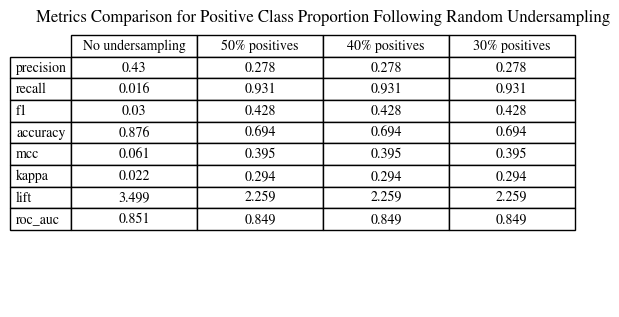

In [131]:
metrics = list(avg_us.keys())

dicts = [avg_no_us, avg_us5, avg_us4, avg_us3]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(5,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['No undersampling', '50% positives', '40% positives', '30% positives'],
                 rowLabels=metrics,cellLoc='center', loc='top')

table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Positive Class Proportion Following Random Undersampling", fontsize=12, pad=150)
plt.show()

plt.show()

Results from k-fold CV with imbalanced validation sets show no difference between positive class representation with undersampling, indicating that additional majority samples did not improve performance, so 50% positive class proportion is used.

Without undersampling, precision, lift and accuracy are higher, reflecting better performance on the majority class, but undersampling significantly improves recall, as the model identifies a much greater proportion of the positives. This is important here where TPR outweights FPR.
F1, MCC and Cohen's Kappa are also higher with undersampling, showing better performance across classes, which ROC/AUC remains similar.

Next, I compare SMOTE.

In [138]:
from imblearn.over_sampling import SMOTE

def smote_oversample_pos(args, X, y, adaboost_labels=True):
    strategy = args.get('smote_strategy', 'minority')
    k_neighbours = args.get('smote_k_neighbours', 5)
    neg, pos = -1 if adaboost_labels else 0, 1
    N_neg = len(y[y == neg])

    smote = SMOTE(sampling_strategy=strategy,
                  k_neighbors=k_neighbours,
                  random_state=args['random_state'])
    X_smote, y_smote = smote.fit_resample(X, y)

    return X_smote, y_smote

In [145]:
# Demonstration
X_os, y_os = smote_oversample_pos(args, X_strat, y_strat)
print("Original imbalance:\n", y_strat.value_counts(), "\n--\nWith SMOTE:\n", y_os.value_counts())

Original imbalance:
 Response
-1    87701
 1    12299
Name: count, dtype: int64 
--
With SMOTE:
 Response
-1    87701
 1    87701
Name: count, dtype: int64


I avoid applying SMOTE to all of the data as this could
inflate validation metrics due to data leakage.

In [137]:
def preprocess_train(args, X_train, y_train):
    # Apply SMOTE to the training folds
    return smote_oversample_pos(args, X_train, y_train)    

In [147]:
adaboosts_50_smote, train_errs_50_smote, val_errs_50_smote, metrics_50_smote, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
print(f"Averages - training error: {np.mean(train_errs_50_smote)}, validation error: {np.mean(val_errs_50_smote)}, validation ROC/AUC: {avg_metrics(metrics_50_smote)['roc_auc']}")

/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


Fold 1 complete.


/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


Fold 2 complete.


/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


Fold 3 complete.


/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


Fold 4 complete.


/tmp/ipykernel_4187184/892535492.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.abs(np.trapz(tpr_list, fpr_list)).item() # integrate with trapezoidal method


Fold 5 complete.
Completed cross-validation in 224.40440464019775 seconds.
Averages - training error: 0.23486750060115194, validation error: 0.351926628589494, validation ROC/AUC: 0.8308


In [151]:
avg_smote = avg_metrics(metrics_50_smote)

SMOTE improves stratified k-fold CV performance. Precision decreases (higher FPR) as well as ROC/AUC slightly, while accuracy without SMOTE is higher but misleading under imbalance. Recall is much higher with SMOTE, with a higher F1 score, and MCC improves, indicating better balance across classes. The slight ROC/AUC drop may reflect some overfitting to synthetic samples.

Next, SMOTE parameters are tuned. `k_neighbors` controls neighbour count for sample generation, and I test 7 and 9 (more diversity but possible noise) and 3.

In [154]:
args['smote_k_neighbours'] = 7
adaboosts_50_smote7, train_errs_50_smote7, val_errs_50_smote7, metrics_50_smote7, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 205.4151964187622 seconds.


In [155]:
avg_smote7 = avg_metrics(metrics_50_smote7)

In [91]:
args['smote_k_neighbours'] = 9
adaboosts_50_smote9, train_errs_50_smote9, val_errs_50_smote9, metrics_50_smote9, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
avg_smote9 = avg_metrics(metrics_50_smote9)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 295.64358592033386 seconds.


In [94]:
args['smote_k_neighbours'] = 3
adaboosts_50_smote3, train_errs_50_smote3, val_errs_50_smote3, metrics_50_smote3, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
avg_smote3 = avg_metrics(metrics_50_smote3)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 288.91093373298645 seconds.


SMOTE can work better when used in combination with
random undersampling of the majority class.

In [206]:
def preprocess_train(args, X_train, y_train):
    X_train, y_train = smote_oversample_pos(args, X_train, y_train)
    X_train, y_train = undersample_neg(args, X_train, y_train)

    return X_train, y_train

In [199]:
# Demonstration
args['smote_strategy'] = 0.5
X_temp, y_temp = smote_oversample_pos(args, X_strat_11f, y_strat)
X_temp, y_temp = undersample_neg(args, X_temp, y_temp)
print(X_temp.shape, y_temp.shape)
print(y_strat.value_counts(), y_temp.value_counts())

(87700, 11) (87700,)
Response
-1    87701
 1    12299
Name: count, dtype: int64 Response
 1    43850
-1    43850
Name: count, dtype: int64


In [205]:
args['smote_strategy'] = 0.5
adaboosts_50_os_us, train_errs_50_os_us, val_errs_50_os_us, metrics_50_os_us, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
avg_os_us = avg_metrics(metrics_50_os_us_11f)
avg_os_us

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 133.18146419525146 seconds.


{'precision': 0.2735902229864211,
 'recall': 0.9196421309475398,
 'f1': 0.421702914758161,
 'accuracy': 0.6898044902245112,
 'mcc': 0.38496813543309927,
 'kappa': 0.2864623361790301,
 'lift': 2.225104054292573,
 'roc_auc': 0.8343246413356933}

In terms of performance, this has landed in between only using SMOTE and only undersampling.

In [184]:
avg_metrics(metrics_50_us_11f)

{'precision': 0.2695863047490263,
 'recall': 0.9498169987799919,
 'f1': 0.4198331838865944,
 'accuracy': 0.6768938446922347,
 'mcc': 0.39022948575279326,
 'kappa': 0.28236075108789255,
 'lift': 2.1925402637965745,
 'roc_auc': 0.8460206566713484}

In [207]:
args['smote_strategy'] = 0.2
adaboosts_50_os_us_2, train_errs_50_os_us_2, val_errs_50_os_us_2, metrics_50_os_us_2, _ = train_adaboost_k_fold(
    args, X_strat_11f, y_strat, stratified=True)
avg_os_us_2 = avg_metrics(metrics_50_os_us_2)
avg_os_us_2

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 63.86627697944641 seconds.


{'precision': 0.2747062486544548,
 'recall': 0.9319235461569745,
 'f1': 0.4243149665423155,
 'accuracy': 0.6890344517225861,
 'mcc': 0.3908987095977544,
 'kappa': 0.28933958513043534,
 'lift': 2.234180669719578,
 'roc_auc': 0.8450844221515638}

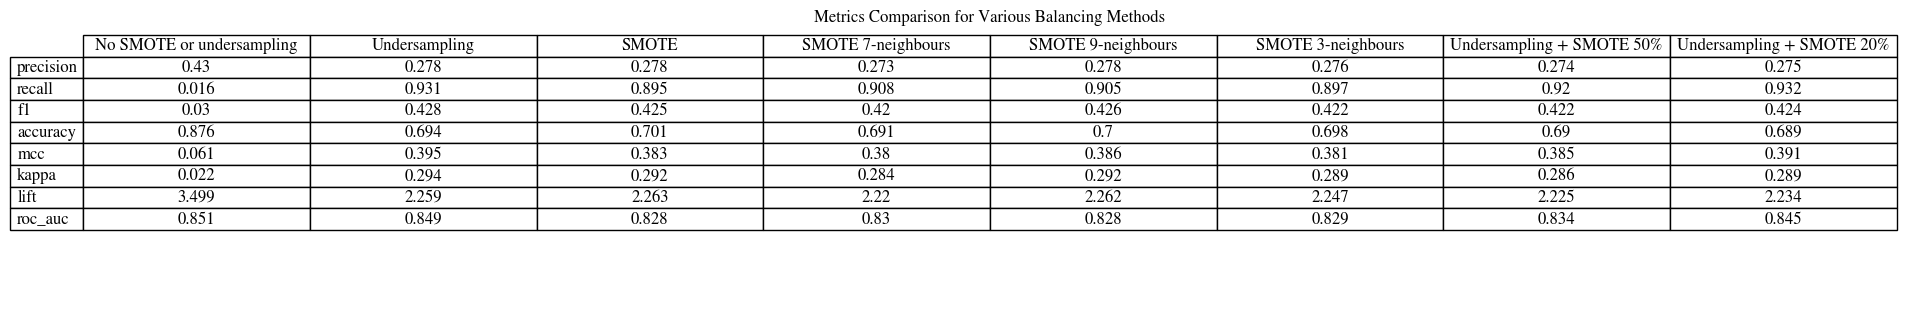

In [175]:
metrics = list(avg_us.keys())

dicts = [avg_no_us, avg_us5, avg_smote, avg_smote7, avg_smote9, avg_smote3, avg_os_us, avg_os_us_2]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(18,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['No SMOTE or undersampling', 'Undersampling', 'SMOTE', 'SMOTE 7-neighbours',
                                           'SMOTE 9-neighbours', 'SMOTE 3-neighbours', 'Undersampling + SMOTE 50%', 'Undersampling + SMOTE 20%'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Various Balancing Methods", fontsize=12, pad=150)
plt.show()

plt.show()

The original imbalanced model fails to identify positives. Undersampling improves recall, precision, and F1 by focusing on the minority class. SMOTE (and variants) increases recall and F1 but reduces precision, as synthetic samples introduce noise. As a result, F1 improves but remains below undersampling due to lower precision.
ROC/AUC is lowest with the original imbalance, improves with SMOTE, but is highest with undersampling, which enhances minority class learning and discrimination without added noise.
Undersampling also has lowest computational cost and is selected, with sample size increased to 500k for further experiments.

In [179]:
def preprocess_train(args, X_train, y_train):
    return undersample_neg(args, X_train, y_train)

In [180]:
args['N'] = 500000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts())


Sampled data
--
 (500000,) Response
-1    438502
 1     61498
Name: count, dtype: int64


## Data scaling

In [181]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_strat_scale = pd.DataFrame(scaler.fit_transform(X_strat))
X_strat_scale.head()

,0,1,2,3,4,5,6,7,8,9
0,-1.024649,0.043538,1.122954,1.077685,-1.061400,-1.004028,0.603195,0.732266,-1.035440,-1.08866
1,0.109228,0.043538,0.121684,-0.927915,0.700225,0.995988,1.125913,0.214469,-1.722910,0.91856
2,-0.891252,0.043538,-0.879586,1.077685,-1.061400,-1.004028,0.556553,0.732266,-1.160434,-1.08866
3,0.976310,0.043538,0.506788,1.077685,0.700225,-1.004028,-1.688213,-1.597821,-1.685412,-1.08866
4,-0.357663,0.043538,-1.418732,-0.927915,-1.061400,0.995988,1.104839,0.732266,0.052013,-1.08866


In [182]:
adaboosts_50_scale_us, train_errs_50_scale_us, val_errs_50_scale_us, metrics_50_scale_us, _ = train_adaboost_k_fold(
    args, X_strat_scale, y_strat, stratified=True)
avg_scale_us = avg_metrics(metrics_50_scale_us)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 216.6138117313385 seconds.


Using undersampling without scaling on 500k samples for comparison:

In [183]:
adaboosts_50_us, train_errs_50_us, val_errs_50_us, metrics_50_us, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
avg_us = avg_metrics(metrics_50_us)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 157.71533703804016 seconds.


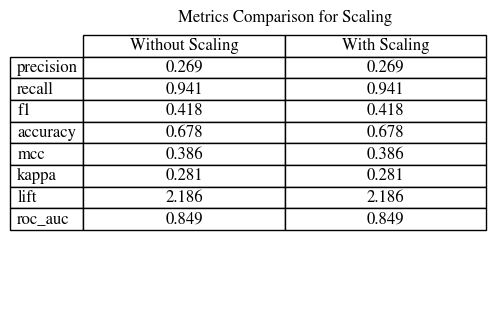

In [188]:
metrics = list(avg_us.keys())

dicts = [avg_us, avg_scale_us]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(4,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['Without Scaling', 'With Scaling'], rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Scaling", fontsize=12, pad=150)
plt.show()

plt.show()

Scaling has no effect on the performance metrics with AdaBoost.
This is because AdaBoost is not sensitive to scaling.
The decision stumps use a single feature and so are not affected by the scale of the data.
Therefore, scaling is not necessary and is not used.

## Feature engineering and selection

In [192]:
X_strat.head(1)

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male
10718678,23,1,41.0,1,0,0,40360.0,152.0,81,0


In [196]:
y_strat.head(3)

10718678   -1
6886384    -1
2920263    -1
Name: Response, dtype: int64

We already removed `id` which has no predictive power, and converted Gender and Vehicle_Age into categorical variables, mapped binary values in Vehicle_Damage from Yes/No to 1/0, and elsewhere mapped True/False to 1/0, and transformed negative responses into -1 for AdaBoost.
This section adds interaction and derived features to encode nonlinear relationships (at the cost of increasing training duration).
I add interactions for all pairwise combinations (e.g. `Age` $\times$ `Gender_Male` captures the combined effect of age and gender on the response, `Vehicle_Age` $\times$ `Vehicle_Damage`, encodes that older vehicles with damage may have a different effect compared to newer vehicles with damage, and `Region_Code` $\times$ `Policy_Sales_Channel` might help determine
if some sales channels are more effective in particular regions than others, helping to locally optimise sales strategy.

Derived features include
`Vintage - Vehicle_Age`,
which calculates customer tenure versus vehicle age,
(where a positive result is a customer whose tenure exceeds their current ownership).
Vehicle Age is nominal, so I map <1 year to 182.5 days, 1-2 years to 547.5 days,
and >2 years to 912.5 days.
`Age * Driving_License` highlights driving experience according to age.
`Annual_Premium / Vehicle_Age` helps assess how premium is related to vehicle age.
`Vintage / Annual_Premium` encodes tenure versus annual premium.

I train AdaBoost on the full feature set and subsequently select features based on their contribution to the most competant weak learners. I use 100k samples here as the feature set is much larger.

In [197]:
args['N'] = 100000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
print('Full training data\n--\n', y.shape, y.value_counts(normalize=True))
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts(normalize=True))

Full training data
--
 (11504798,) Response
0    0.877003
1    0.122997
Name: proportion, dtype: float64

Sampled data
--
 (100000,) Response
-1    0.87701
 1    0.12299
Name: proportion, dtype: float64


In [201]:
import itertools

def interact(f1, f2):
    f1f2 = f1.astype(str) + f2.astype(str)
    return pd.factorize(f1f2)[0] + 1

def create_insurance_features(df):
    df = df.copy()

    # Interaction features
    cols = df.columns
    for f1, f2 in itertools.combinations(cols, 2):
        df[f'{f1}_{f2}'] = interact(df[f1], df[f2])
        df = df.copy()

    # Derived features
    df['Vintage_minus_Vehicle_Age'] = df['Vintage'] - df['Vehicle_Age'].map({0:182.5, 1:547.5, 2: 912.5})
    df['Age_times_Driving_License'] = df['Age'] * df['Driving_License']
    df['Annual_Premium_per_Vehicle_Age'] = df['Annual_Premium'] / (df['Vehicle_Age'] + 1)  # +1 to avoid division by 0
    df['Vintage_per_Annual_Premium'] = df['Vintage'] / (df['Annual_Premium'] + 1)
    
    return df

In [206]:
X_strat_full_feats = create_insurance_features(X_strat)
X_strat_full_feats.head(1)

,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,...,Annual_Premium_Policy_Sales_Channel,Annual_Premium_Vintage,Annual_Premium_Gender_Male,Policy_Sales_Channel_Vintage,Policy_Sales_Channel_Gender_Male,Vintage_Gender_Male,Vintage_minus_Vehicle_Age,Age_times_Driving_License,Annual_Premium_per_Vehicle_Age,Vintage_per_Annual_Premium
9587897,59,1,28.0,0,2,1,37349.0,124.0,83,1,...,1,1,1,1,1,1,-829.5,59,12449.666667,0.002222


In [203]:
X_strat_full_feats.shape

(100000, 59)

The number of features has increased from 10 to 59. Next, I determine if any of the added features improve performance.

In [207]:
adaboosts_50_full_feats,train_errs_50_full_feats, val_errs_50_full_feats, metrics_50_full_feats, _ = train_adaboost_k_fold(
    args, X_strat_full_feats, y_strat, stratified=True)
avg_full_feat = avg_metrics(metrics_50_full_feats)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 365.1750500202179 seconds.


The following function uses AdaBoost for automatic feature selection. For each CV fold, it gets
mean $\alpha$ for each feature, then averages these over folds to
sort features by the average competance of their corresponding weak classifiers.

In [212]:
def avg_alpha(classifiers):
    alpha_sum = pd.DataFrame()

    for classifier in classifiers:
        alpha = classifier.groupby('feature')['alpha'].mean()
        alpha_sum = pd.concat([alpha_sum, alpha], axis=1)

    alpha_avg = alpha_sum.mean(axis=1)
    alpha_avg = alpha_avg.sort_values(ascending=False)

    # Rename the columns to 'feature' and 'alpha'
    alpha_avg = alpha_avg.reset_index()
    alpha_avg.columns = ['feature', 'alpha']

    return alpha_avg

In [214]:
avg_alpha(adaboosts_50_full_feats).iloc[:5]

,feature,alpha
0,43.0,0.348641
1,34.0,0.302021
2,35.0,0.246091
3,55.0,0.223779
4,11.0,0.137797


From this, the features associated with the five highest average competance weak classifiers were:

In [218]:
best_additional = X_strat_full_feats.columns[[43, 34, 35, 55, 11]]
best_additional

Index(['Vehicle_Age_Vintage', 'Previously_Insured_Vehicle_Age',
       'Previously_Insured_Vehicle_Damage', 'Vintage_minus_Vehicle_Age',
       'Age_Region_Code'],
      dtype='object')

Removing the other additional features, we get the following set:


In [233]:
X_strat_15f = X_strat_full_feats[X_strat.columns.union(best_additional)]
X_strat_15f.head(1)

,Age,Age_Region_Code,Annual_Premium,Driving_License,Gender_Male,Policy_Sales_Channel,Previously_Insured,Previously_Insured_Vehicle_Age,Previously_Insured_Vehicle_Damage,Region_Code,Vehicle_Age,Vehicle_Age_Vintage,Vehicle_Damage,Vintage,Vintage_minus_Vehicle_Age
9587897,59,1,37349.0,1,1,124.0,0,1,1,28.0,2,1,1,83,-829.5


In [235]:
adaboosts_50_15f,train_errs_50_15f, val_errs_50_15f, metrics_50_15f, _ = train_adaboost_k_fold(
    args, X_strat_15f, y_strat, stratified=True)
avg_15f = avg_metrics(metrics_50_15f)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 70.12262415885925 seconds.


Taking only the most important additional feature:

In [252]:
avg_alpha(adaboosts_50_15f).iloc[:1]

,feature,alpha
0,7.0,0.302021


In [257]:
best_single_additional = X_strat_15f.columns[[7]]
best_single_additional

Index(['Previously_Insured_Vehicle_Age'], dtype='object')

In [258]:
X_strat_11f = X_strat_full_feats[X_strat.columns.union(best_single_additional)]
X_strat_11f.head(1)

,Age,Annual_Premium,Driving_License,Gender_Male,Policy_Sales_Channel,Previously_Insured,Previously_Insured_Vehicle_Age,Region_Code,Vehicle_Age,Vehicle_Damage,Vintage
9587897,59,37349.0,1,1,124.0,0,1,28.0,2,1,83


In [259]:
adaboosts_50_11f,train_errs_50_11f, val_errs_50_11f, metrics_50_11f, _ = train_adaboost_k_fold(
    args, X_strat_11f, y_strat, stratified=True)
avg_11f = avg_metrics(metrics_50_11f)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 47.43832588195801 seconds.


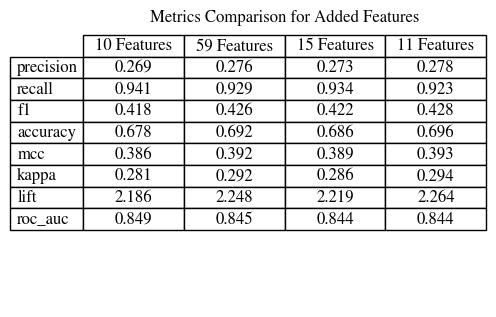

In [270]:
metrics = list(avg_us.keys())

dicts = [avg_us, avg_full_feat, avg_15f, avg_11f]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(4,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['10 Features', '59 Features', '15 Features', '11 Features'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Added Features", fontsize=12, pad=150)
plt.show()

plt.show()

Overall, adding one interaction feature between `Previously_Insured` and `Vehicle_Age` produced the best
F1 score, accuracy, MCC, Kappa, and lift, indicating a good balance between precision and recall.
However, the origial 10-features set has the best ROC/AUC. Since this is a priority for the competition, I
continue with the original features. 

## Analyse and report how the performance of the model changes with different feature subsets. 

Feature subsets can be chosen automatically or manually based on domain knowledge.
For example, we can automatically choose features corresponding to the most competent
weak classifires. Alternatively, we can manually select features
already believed to be important, or group certain features together, such as demographic 
versus vehicle-related.
With the original features, I compare performance with exclusively
demographic or vehicle features. Then, I automatically select features and compare performance across subsets.
For each subset, I fit an AdaBoost
model and use stratified k-fold CV with the original imbalance.

#### Original feature set

I train a 50-round AdaBoost model on the original features using stratified k-fold cross-validation.
The average performance on various metrics across validation sets is shown below.

In [251]:
adaboosts_50_us, train_errs_50_us, val_errs_50_us, metrics_50_us, _ = train_adaboost_k_fold(
    args, X_strat, y_strat, stratified=True)
avg_metrics(metrics_50_us)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 203.67933297157288 seconds.


{'precision': 0.27041015878109387,
 'recall': 0.9450687047727457,
 'f1': 0.4203578372482563,
 'accuracy': 0.6790367903679038,
 'mcc': 0.38957335919853253,
 'kappa': 0.28325829350513543,
 'lift': 2.1986133399423213,
 'roc_auc': 0.8487484275079424}

### Manual feature subset selection

#### Training models on exclusively demographic or car-related features

I consider the demographic features
Age, Gender, Driving_License, Region_Code, Previously_Insured,
and Vintage(as this relates to customer history),
and car-related features
Vehicle_Age, Vehicle_Damage, Annual_Premium.
Policy_Sales_Channel is a marketing-related feature and does not fit well
into either category and so is left out of this experiment.

In [261]:
X_dem = X_strat[['Age', 'Gender_Male', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vintage']]
X_car = X_strat[['Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium']]

In [275]:
adaboosts_50_us_dem, train_errs_50_us_dem, val_errs_50_us_dem, metrics_50_us_dem, _ = train_adaboost_k_fold(
    args, X_dem, y_strat, stratified=True)
avg_metrics(metrics_50_us_dem)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 142.889577627182 seconds.


{'precision': 0.2633,
 'recall': 0.9205399999999999,
 'f1': 0.40946,
 'accuracy': 0.6734000000000001,
 'mcc': 0.37104,
 'kappa': 0.2698,
 'lift': 2.14074,
 'roc_auc': 0.83224}

In [269]:
adaboosts_50_us_car, train_errs_50_us_car, val_errs_50_us_car, metrics_50_us_car, _ = train_adaboost_k_fold(
    args, X_car, y_strat, stratified=True)
avg_metrics(metrics_50_us_car)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 125.18378233909607 seconds.


{'precision': 0.24086,
 'recall': 0.98316,
 'f1': 0.38696,
 'accuracy': 0.6168600000000001,
 'mcc': 0.3604,
 'kappa': 0.23601999999999998,
 'lift': 1.95854,
 'roc_auc': 0.80762}

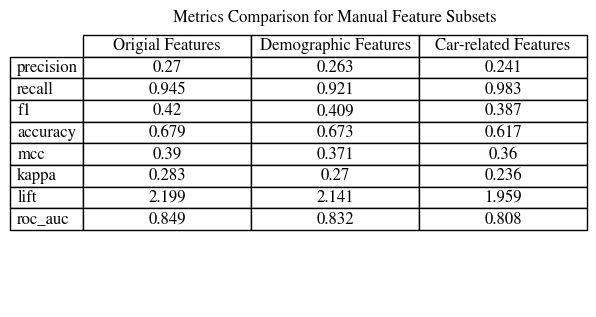

In [275]:
metrics = list(avg_50_us.keys())

dicts = [avg_50_us, avg_us_dem, avg_50_us_car]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(5,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['Origial Features', 'Demographic Features', 'Car-related Features'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Manual Feature Subsets", fontsize=12, pad=150)
plt.show()

plt.show()

Using all features performs best across nearly all metrics. Demographic-only features outperform car-only features in most metrics, with better recall but lower precision and F1 than the full set. Car features achieve high recall but generate more false positives and perform worst overall.
However, there are 6 demographic versus only 3 car features. For a fairer compairson, I select the top 3 demographic features using average cross-fold classifier competence.

In [306]:
avg_alpha(adaboosts_50_us_dem)

,feature,alpha
0,4.0,0.177796
1,0.0,0.098047
2,5.0,0.067577
3,3.0,0.059667
4,1.0,0.025850


This has returned the best demographic features as 4: `Previously_Insured`; 0: `Age`; and 5: `Vintage`.
I now train a model on these features.

In [310]:
X_dem_3f = X_dem[['Previously_Insured', 'Age', 'Vintage']]
adaboosts_50_us_dem_3f, train_errs_50_us_dem_3f, val_errs_50_us_dem_3f, metrics_50_us_dem_3f, _ = train_adaboost_k_fold(
    args, X_dem_3f, y_strat, stratified=True)
avg_metrics(metrics_50_us_dem_3f)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 113.3655514717102 seconds.


{'precision': 0.26198,
 'recall': 0.9204199999999998,
 'f1': 0.40786,
 'accuracy': 0.67126,
 'mcc': 0.36916000000000004,
 'kappa': 0.26762,
 'lift': 2.1301200000000002,
 'roc_auc': 0.8297799999999999}

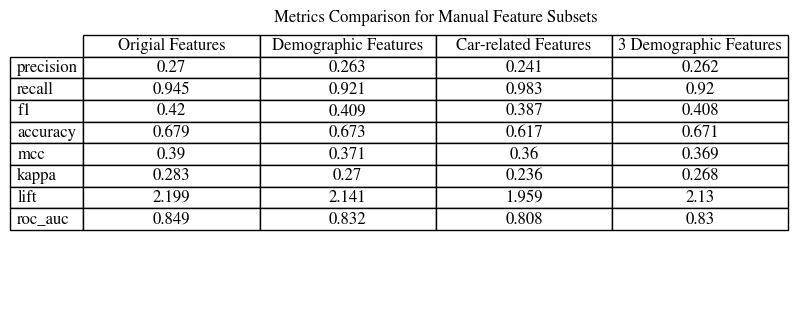

In [279]:
metrics = list(avg_50_us.keys())

dicts = [avg_50_us, avg_us_dem, avg_50_us_car, avg_dem_3f]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(7,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['Origial Features', 'Demographic Features', 'Car-related Features', '3 Demographic Features'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.3)
plt.title("Metrics Comparison for Manual Feature Subsets", fontsize=12, pad=150)
plt.show()

plt.show()

Removing 3 demographic features reduced performance only slightly,
which remained better than car features, signalling greater importance of
demographic features than car features in the context of selling car insurance.
However, the performance is worse than with all features, so both types are useful.

### Automatic feature subset selection

By applying avg_alpha to the model trained on the full feature set, automatic feature selection is performed by
way of comparing the average competance of the features' associated weak classifier(s).

In [366]:
avg_alpha_full = avg_alpha(adaboosts_50_us)
avg_alpha_full

,feature,alpha
0,5.0,0.618266
1,7.0,0.116405
2,3.0,0.110733
3,4.0,0.107839
4,6.0,0.093462
5,0.0,0.088715
6,2.0,0.076609
7,8.0,0.074000


In [368]:
print(X_strat.columns[[8,2,0,6]])

Index(['Vintage', 'Region_Code', 'Age', 'Annual_Premium'], dtype='object')


Features 1: Driving_License and 9: Gender were not used, so removing these should not affect the performance.
Of the features considered, 8: Vintage was associated with the least compatent weak classifiers on average.

In [344]:
auc_scoares = [0.5 for i in range(X_strat.shape[1])]
auc_scores[0] = avg_metrics(metrics_50_us_11f)['roc_auc']

In [347]:
X_reduced_1 = X_strat.drop(['Driving_License', 'Gender_Male'], axis=1)
adaboosts_50_us_r1, train_errs_50_us_r1, val_errs_50_us_r1, metrics_50_us_r1, _ = train_adaboost_k_fold(
    args, X_reduced_1, y_strat, stratified=True)
auc_scores[1] = avg_metrics(metrics_50_us_r1)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 205.79895544052124 seconds.


In [349]:
avg_metrics(metrics_50_us_r1)

{'precision': 0.27040000000000003,
 'recall': 0.9450800000000001,
 'f1': 0.42034000000000005,
 'accuracy': 0.67904,
 'mcc': 0.38956,
 'kappa': 0.28328,
 'lift': 2.1986,
 'roc_auc': 0.8487399999999999}

Indeed, the performance did not change after removing these two features. Removing Vintage:

In [365]:
X_reduced_2 = X_reduced_1.drop('Vintage', axis=1)
adaboosts_50_us_r2, train_errs_50_us_r2, val_errs_50_us_r2, metrics_50_us_r2, _ = train_adaboost_k_fold(
    args, X_reduced_2, y_strat, stratified=True)
auc_scores[2] = avg_metrics(metrics_50_us_r2)['roc_auc']
avg_metrics(metrics_50_us_r2)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 180.78978514671326 seconds.


{'precision': 0.2756,
 'recall': 0.93326,
 'f1': 0.4255,
 'accuracy': 0.6899599999999999,
 'mcc': 0.39252000000000004,
 'kappa': 0.29086,
 'lift': 2.2408200000000003,
 'roc_auc': 0.8480800000000001}

ROC/AUC and recall very slightly declined but other metrics improved with the removal of this feature.
Removing Region_Code:

In [369]:
X_reduced_3 = X_reduced_2.drop('Region_Code', axis=1)
adaboosts_50_us_r3, train_errs_50_us_r3, val_errs_50_us_r3, metrics_50_us_r3, _ = train_adaboost_k_fold(
    args, X_reduced_3, y_strat, stratified=True)
auc_scores[3] = avg_metrics(metrics_50_us_r3)['roc_auc']
avg_metrics(metrics_50_us_r3)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 199.97486853599548 seconds.


{'precision': 0.27562000000000003,
 'recall': 0.9332600000000001,
 'f1': 0.42552,
 'accuracy': 0.68996,
 'mcc': 0.39252000000000004,
 'kappa': 0.29086,
 'lift': 2.2408799999999998,
 'roc_auc': 0.84812}

Removing Region_Code and Vintage gave similar results to removing only Vintage. Removing Age:

In [370]:
X_reduced_4 = X_reduced_3.drop('Age', axis=1)
adaboosts_50_us_r4, train_errs_50_us_r4, val_errs_50_us_r4, metrics_50_us_r4, _ = train_adaboost_k_fold(
    args, X_reduced_4, y_strat, stratified=True)
auc_scores[4] = avg_metrics(metrics_50_us_r4)['roc_auc']
avg_metrics(metrics_50_us_r4)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 127.48220133781433 seconds.


{'precision': 0.25266,
 'recall': 0.98174,
 'f1': 0.40188000000000007,
 'accuracy': 0.6406000000000001,
 'mcc': 0.37771999999999994,
 'kappa': 0.2564,
 'lift': 2.0543,
 'roc_auc': 0.8248200000000001}

After removing Age, we begin to see reductions in performance. Looking at the table below, we can notice that for 0: Age, the average alpha across folds was 0.089 compared to 0.077 and 0.074 for Region_Code and Vintage respectively.

In [372]:
avg_alpha_full

,feature,alpha
0,5.0,0.618266
1,7.0,0.116405
2,3.0,0.110733
3,4.0,0.107839
4,6.0,0.093462
5,0.0,0.088715
6,2.0,0.076609
7,8.0,0.074000


In [377]:
X_reduced_5 = X_reduced_4.drop('Annual_Premium', axis=1)
adaboosts_50_us_r5, train_errs_50_us_r5, val_errs_50_us_r5, metrics_50_us_r5, _ = train_adaboost_k_fold(
    args, X_reduced_5, y_strat, stratified=True)
auc_scores[5] = avg_metrics(metrics_50_us_r5)['roc_auc']
avg_metrics(metrics_50_us_r5)

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 104.5312774181366 seconds.


{'precision': 0.25266,
 'recall': 0.98174,
 'f1': 0.40187999999999996,
 'accuracy': 0.6406000000000001,
 'mcc': 0.37771999999999994,
 'kappa': 0.25639999999999996,
 'lift': 2.0543,
 'roc_auc': 0.82478}

Additionally removing Annual_Premium had little impact on the performance.

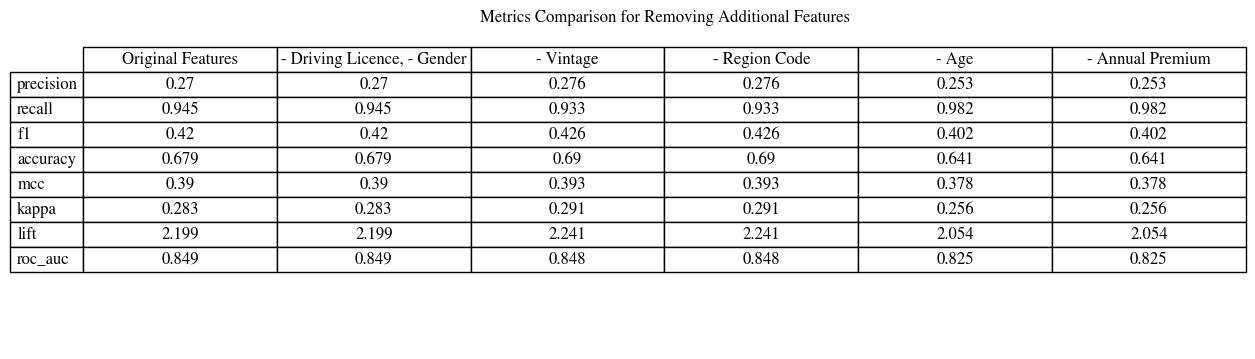

In [294]:
metrics = list(avg_r1.keys())

dicts = [avg_50_us, avg_r1, avg_r2, avg_r3, avg_r4, avg_r5]
data = np.array([[d[metric] for d in dicts] for metric in metrics])
data = np.round(data, 3)

fig, ax = plt.subplots(figsize=(10,1))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=data, colLabels=['Original Features', '- Driving Licence, - Gender', '- Vintage', '- Region Code', '- Age', '- Annual Premium'],
                 rowLabels=metrics,cellLoc='center', loc='top')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
plt.title("Metrics Comparison for Removing Additional Features", fontsize=12, pad=180)
plt.show()

plt.show()

Removing Driving_License and Gender had no effect since they were not used
Removing Vintage saw a very slight decline in ROC/AUC only. Additionally removing Region Code showed similar results to only removing Vintage.
However, removing Age saw a marked decrease in performance, as we would expect by the relatively high $\alpha$ values. Also removing Annual Premium did not affect performance much.

## Other enhancements

### Decision tree weak-classifiers; removing easy and difficult samples

train_adaboost adds shallow tree classifiers and the removal of easy samples
every $n$ rounds (see 00_adaboost_impl.ipynb).
Added also are dynamic removal of hard samples every $m$ rounds.
AdaBoost may fit to outliers and noise, so removing hard samples may reduce overfitting and 
improve generalisation by smoothing the decision boundary to better reflect
underlying patterns in the data. And with fewer samples, the model can converge more efficiently.

The following function also avoids creating temporary strong classifiers to improve training time.
Unlike the earlier version, which built a full ensemble then iterated over weak learners, this version calculates the strong classifiers within the main loop.

In [39]:
def remove_easy_samples(args, X, y, h, alpha, weight, pred_df):
    remove_threshold = args.get('easy_threshold', 0.8)

    # Get the confidences
    margins = pred_df[['sum_alpha','pos_votes','neg_votes']].apply(
        lambda x: margin_calculation(*x), axis=1)

    # Remove the samples with confidences at or above the threshold
    keep_idx = [i for i in range(len(X)) if margins[i] < remove_threshold]

    N_removed = len(X) - len(keep_idx)
    
    if not args.get('silent', False):
        print(f"Removed {N_removed} sample(s) with confidence at or above {remove_threshold}.")

    return X.iloc[keep_idx], y.iloc[keep_idx], weight[keep_idx], N_removed


def remove_hard_samples(args, X, y, h, alpha, weight, pred_df):
    remove_threshold = args.get('hard_threshold', 0.4)

    # Get the confidences
    margins = pred_df[['sum_alpha', 'pos_votes', 'neg_votes']].apply(
        lambda x: margin_calculation(*x), axis=1)

    # Remove samples below remove threshold
    keep_idx = [i for i in range(len(X)) if margins[i] > remove_threshold]

    N_removed = len(X) - len(keep_idx)
    
    if not args.get('silent', False):
        print(f"Removed {N_removed} sample(s) with confidence at or below {remove_threshold}.")

    return X.iloc[keep_idx], y.iloc[keep_idx], weight[keep_idx], N_removed

In [48]:
def initialise_param(args, N, tree=False):
    return reset_param_tree(args, N) if tree else reset_param(args, N)


def create_strong_classifier(h, alpha, tree=False):
    if tree:
        classifier = pd.DataFrame(h, columns=['decision_tree'])
    else:
        classifier = pd.DataFrame(h, columns=['threshold', 'feature', 'direction'])
    
    classifier['alpha'] = alpha

    return classifier

def removal_reindex(csum, pos, neg, X, label):
    # To be called after removing samples
    indices = X.index.tolist()
    csum = np.array(csum[indices])
    pos = np.array(pos[indices])
    neg = np.array(neg[indices])
    X = X.reset_index(drop=True)
    label = label.reset_index(drop=True)

    return csum, pos, neg, X, label

def remove_print(args, N_removed_easy, N_removed_hard):
    easy = args.get('remove_easy', False)
    hard = args.get('remove_hard', False)
    if not easy and not hard: return
    if easy: print(f"Removed {N_removed_easy} easy sample(s) during training.")
    if hard: print(f"Removed {N_removed_hard} hard sample(s) during training.")
    

def train_adaboost(args, X, label, X_val, label_val):
    silent = args.get('silent', False)
    early_stopping = args.get('early_stopping', False)
    remove_easy = args.get('remove_easy', False)
    remove_hard = args.get('remove_hard', False)
    tree = args.get('decision_tree', False)

    T = args['T']
    X = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    label = label if isinstance(label, pd.Series) else pd.Series(label)
    N, n_feat = X.shape
    N_val = len(X_val)
    N_removed_easy, N_removed_hard = 0, 0

    visualiser = Visualiser(N, N_val, T)
    es = EarlyStopping(args)
    
    h, alpha, err, weight = initialise_param(args, N, tree)
    
    train_err = np.array([None] * (T+1), dtype=float)
    train_err[0] = 1.0
    val_err = np.array([None] * (T+1), dtype=float)
    val_err[0] = 1.0
     
    classification_sum = np.zeros(N)
    pos_votes = np.zeros(N, dtype=np.float64)
    neg_votes = np.zeros(N, dtype=np.float64)

    classification_sum_val = np.zeros(N_val)
    pos_votes_val = np.zeros(N_val, dtype=np.float64)
    neg_votes_val = np.zeros(N_val, dtype=np.float64)

    for t in range(T):
        if tree:
            tree = calculate_decision_tree(args, X, label, weight)
            ht = tree.predict(X)
            ht_val = tree.predict(X_val)
            
            # Calculate weighted error
            misclassifications = (ht != label).astype(int)
            weighted_error = (misclassifications * weight).sum()
            
            err[t] = weighted_error
            h[t] = tree
            
        else:
            for feature in range(n_feat):
                threshold, sign, weighted_error = calculate_decision_stump(
                    args, X.iloc[:, feature], weight, label)
         
                if weighted_error < err[t] :
                    err[t] = weighted_error
                    h[t] = [threshold, feature, sign]

            best_thresh, best_feature, best_sign = h[t][0], int(h[t][1]), h[t][2]
            ht = np.sign(X.iloc[:, int(best_feature)] - best_thresh) * best_sign
            ht_val = np.sign(X_val.iloc[:, int(best_feature)] - best_thresh) * best_sign

        alpha[t] = calculate_alpha(args, err[t])

        # Calculate total errors
        classification_sum += alpha[t] * ht
        classification_sum_val += alpha[t] * ht_val
        final_label = np.sign(classification_sum)
        final_label_val = np.sign(classification_sum_val)     
        train_err[t+1] = np.sum(np.float64(final_label != np.array(label))) / N
        val_err[t+1] = np.sum(np.float64(final_label_val != np.array(label_val))) / N_val
        
        pos_votes += np.where(ht == 1, alpha[t], 0)
        neg_votes += np.where(ht == -1, alpha[t], 0)
        sum_alpha = pos_votes - neg_votes
        train_pred = pd.DataFrame({
            'classifications': final_label,
            'pos_votes': pos_votes,
            'neg_votes': neg_votes,
            'sum_alpha': sum_alpha
        })
      
        weight = update_weights(args, weight, alpha[t], ht, label)
        weight = normalise_weights(weight)
        
        if not silent:   
            visualiser.print_info_no_compute(t, err[t], train_err[t+1], val_err[t+1])
            
        if early_stopping:
            
            pos_votes_val += np.where(ht_val == 1, alpha[t], 0)
            neg_votes_val += np.where(ht_val == -1, alpha[t], 0)
            sum_alpha_val = pos_votes_val - neg_votes_val
            val_pred = pd.DataFrame({
                'classifications': final_label_val,
                'pos_votes': pos_votes_val,
                'neg_votes': neg_votes_val,
                'sum_alpha': sum_alpha_val
            })
            
            classifier = create_strong_classifier(h, alpha, tree)
            
            if es.check(val_pred, label_val, classifier, train_err, val_err) == 'stop':
                best_classifier, best_train_err, best_val_err = es.get_best()
                if not silent: remove_print(args, N_removed_easy, N_removed_hard)
                return best_classifier, best_train_err, best_val_err

        if remove_easy:
            n = args.get('remove_easy_every_n_rounds', float('inf'))
            if (t + 1) != T and (t + 1) % n == 0: 
                X, label, weight, N_removed = remove_easy_samples(args, X, label, h, alpha, weight, train_pred)
                classification_sum, pos_votes, neg_votes, X, label = removal_reindex(
                    classification_sum, pos_votes, neg_votes, X, label)
                N_removed_easy += N_removed

        if remove_hard:
            m = args.get('remove_hard_every_m_rounds', float('inf'))
            if (t + 1) != T and (t + 1) % m == 0: 
                X, label, weight, N_removed = remove_hard_samples(args, X, label, h, alpha, weight, train_pred)
                classification_sum, pos_votes, neg_votes, X, label = removal_reindex(
                    classification_sum, pos_votes, neg_votes, X, label)
                N_removed_hard += N_removed
        
        if not silent: print('\n')
            
    if not silent: remove_print(args, N_removed_easy, N_removed_hard)

    classifier = create_strong_classifier(h, alpha, tree)
    
    return classifier, train_err, val_err



### Learning rate parameter

I also add a tunable $\eta$ parameter for the weak-classifier competance calculation.
This controls the contribution from each weak learner to the final prediction and
how much to increase the weights of misclassified samples.
Lower $\eta$ can reduce overfitting and improve generalisation by forcing the model learn more gradually, preventing giving undue influence to outliers, and increasing training stability.

In [215]:
def calculate_alpha(args, weighted_error):
    lr = args.get('learning_rate', 1.0)
    alpha = 0.5 * np.log((1.0 - weighted_error) / weighted_error)
    
    return lr * alpha

In [391]:
# For example, suppose the error is 0.45. The alpha values
# for different learning rates are shown below

for lr in [1.0, 0.5, 0.1, 0.01]:
    args['learning_rate'] = lr
    print(f'Learning rate is {lr}. Alpha = {calculate_alpha(args, 0.45):.4f}')

Learning rate is 1.0. Alpha = 0.1003
Learning rate is 0.5. Alpha = 0.0502
Learning rate is 0.1. Alpha = 0.0100
Learning rate is 0.01. Alpha = 0.0010


The added hyperparamters will be tuned further down. $\eta$ is a tunable factor that affects the competance of individual weak classifiers. Lower values reduce each learner's contribution, improving generalisation and robustness, while requiring more estimators to reach convergence.
There is a trade-off with the number of estimators. High $\eta$ may cause the model to converge prematurely and miss the optimal solution while low $\eta$ increases computeational cost, and risks getting stuck in local minima and fitting to noise in the data.

### Increase multiple

Only one weight factor needs to be tuned (see `00_adaboost_impl.ipynb`). This controls the emphasis on misclassified samples. Increasing the focus on difficult samples 
may help to reduce bias and enhance generalisation, avoiding
focusing on noise and outliers. Tuning calibrates how aggressively the model focuses on such samples.

In [296]:
def update_weights(args, weight, alpha, classification, label):
    weight = weight.copy()
    increase_multiple = args.get('increase_multiple', 1.0)
    
    for i in range(len(weight)):
        if classification[i] != label.iloc[i]:
            weight[i] *= np.exp(increase_multiple * alpha.item())
        else:
            weight[i] *= np.exp(-alpha.item())
    return weight

### Alternative weak-learner loss functions

Decision trees may use a different criteria to evaluate splits while training
and I treat the criterion as a tunable parameter.
The original decision stump uses the weighted error rate as its criterion, which
is the total weight of the misclassified samples.
I add Gini Impurity, Entropy, and Logarithmic Loss.

## Tuning AdaBoost

### Weak-learner depth and criterion

I perform a grid search of tree depth and the loss function, with
max_depth $\in \{1,2,3\}$,
loss_function $\in \{$gini, entropy, log_loss$\}$,
for 9 models plus the original decision stump with weighted error.

Each model is trained with 5-fold CV, with downsampled training folds and stratified validation folds.

In [52]:
import time

def train_adaboost_depth_criteria(args, X, y):
    max_depth, criterion = args['max_depth'], args['criterion']
    _, _, _, val_metrics, _ = train_adaboost_k_fold(args, X, y, stratified=True)
    avg_val_metrics = avg_metrics(val_metrics)
    
    return max_depth, criterion, avg_val_metrics


def search_best_depth_criteria(args, max_depths, criteria, X, y, metric='roc_auc'):
    start_time = time.time()

    local_args = args.copy()
    local_args['silent'] = True
    
    best_score, best_result = 0, {}
    results = {}
    print(f"Searching for the best cross-validation {metric}...")
    
    for max_depth in max_depths:
        for criterion in criteria:
            current_args = local_args.copy()
            current_args['max_depth'] = max_depth
            current_args['criterion'] = criterion
            
            max_depth, criterion, avg_val_metrics = train_adaboost_depth_criteria(current_args, X, y)
            results[f'max_depth={max_depth}_criterion={criterion}'] = avg_val_metrics

            score = avg_val_metrics[metric]

            print(f"max_depth: {max_depth}, criterion: {criterion}, score: {score}")
            
            if score > best_score:
                best_result = {'max_depth': max_depth, 'criterion': criterion, 'score': score}
                best_score = score

    elapsed_time = time.time() - start_time

    print(f"Search took {elapsed_time:.4f} seconds.")
    print(f"Best model was {best_result}")
    print("Best metrics:", results[f'max_depth={best_result['max_depth']}_criterion={best_result['criterion']}'])

    return best_result, results, elapsed_time

In [54]:
args['decision_tree'] = True,
args['T'] = 50
best_depth_criterion, depths_criteria, _ = search_best_depth_criteria(args, [1, 2, 3], ['gini', 'entropy', 'log_loss'], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
max_depth: 1, criterion: gini, score: 0.8469
max_depth: 1, criterion: entropy, score: 0.8472799999999999
max_depth: 1, criterion: log_loss, score: 0.8472799999999999
max_depth: 2, criterion: gini, score: 0.8588600000000002
max_depth: 2, criterion: entropy, score: 0.85854
max_depth: 2, criterion: log_loss, score: 0.85854
max_depth: 3, criterion: gini, score: 0.8618
max_depth: 3, criterion: entropy, score: 0.86262
max_depth: 3, criterion: log_loss, score: 0.86262
Search took 809.2522 seconds.
Best model was {'max_depth': 3, 'criterion': 'entropy', 'score': 0.86262}
Best metrics: {'precision': 0.29033999999999993, 'recall': 0.9223399999999999, 'f1': 0.44166000000000005, 'accuracy': 0.71318, 'mcc': 0.40804, 'kappa': 0.31316, 'lift': 2.3607199999999997, 'roc_auc': 0.86262}


No overfitting by depth 3, so I search at depth 4:

In [57]:
best_depth_criterion2, depths_criteria2, _ = search_best_depth_criteria(args, [4], ['gini', 'entropy', 'log_loss'], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
max_depth: 4, criterion: gini, score: 0.8636800000000001
max_depth: 4, criterion: entropy, score: 0.86374
max_depth: 4, criterion: log_loss, score: 0.86374
Search took 260.7302 seconds.
Best model was {'max_depth': 4, 'criterion': 'entropy', 'score': 0.86374}
Best metrics: {'precision': 0.29408, 'recall': 0.9158200000000001, 'f1': 0.44522000000000006, 'accuracy': 0.71928, 'mcc': 0.41048000000000007, 'kappa': 0.31829999999999997, 'lift': 2.39112, 'roc_auc': 0.86374}


Again, the performance improved with the increased depth. Depths 5 - 7:

In [119]:
best_depth_criterion3, depths_criteria3, _ = search_best_depth_criteria(args, [5, 6, 7], ['gini', 'entropy', 'log_loss'], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
max_depth: 5, criterion: gini, score: 0.8643999999999998
max_depth: 5, criterion: entropy, score: 0.86538
max_depth: 5, criterion: log_loss, score: 0.86538
max_depth: 6, criterion: gini, score: 0.8642199999999999
max_depth: 6, criterion: entropy, score: 0.8638600000000001
max_depth: 6, criterion: log_loss, score: 0.8638600000000001
max_depth: 7, criterion: gini, score: 0.8623199999999999
max_depth: 7, criterion: entropy, score: 0.86222
max_depth: 7, criterion: log_loss, score: 0.8622200000000001
Search took 899.9936 seconds.
Best model was {'max_depth': 5, 'criterion': 'entropy', 'score': 0.86538}
Best metrics: {'precision': 0.29302, 'recall': 0.9204000000000001, 'f1': 0.4445, 'accuracy': 0.7170599999999999, 'mcc': 0.41075999999999996, 'kappa': 0.31710000000000005, 'lift': 2.38242, 'roc_auc': 0.86538}


Depth-5 trees with entropy or log loss gave best CV performance.
Beyond depth 5, performance decreased indicating overfitting to the training data.

In [168]:
depths_criteria_combined = {**depths_criteria, **depths_criteria2, **depths_criteria3}
depths_criteria_combined['max_depth=1_criterion=weighted_error'] = {'roc_auc': 0.85308} # obtained earlier in the notebook

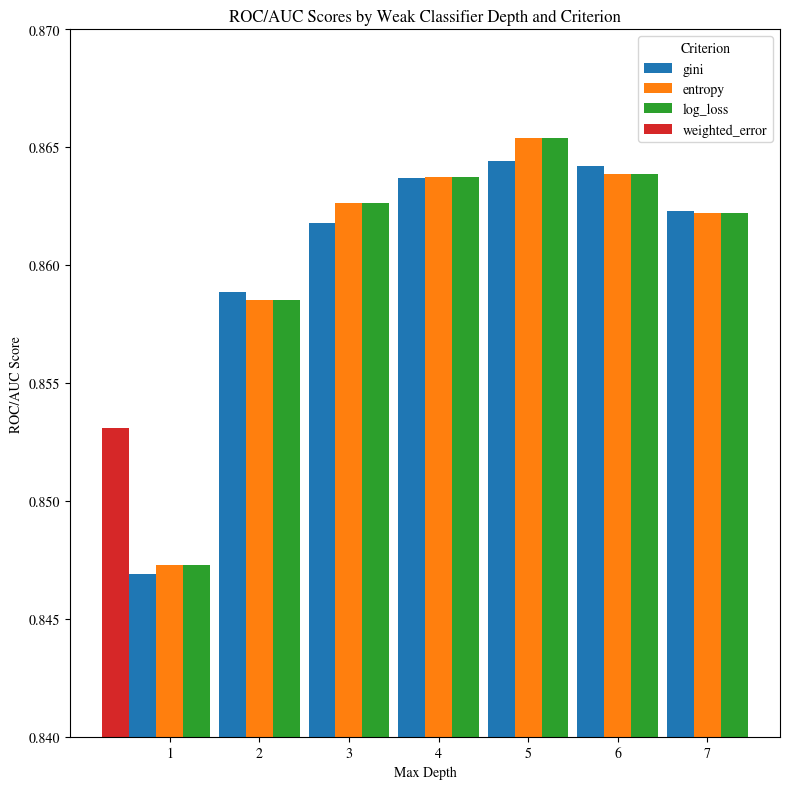

In [167]:
import matplotlib.pyplot as plt
import numpy as np

depths = [d + 1 for d in range(7)]
criteria = ['gini', 'entropy', 'log_loss', 'weighted_error']
roc_auc_scores = {depth: [] for depth in depths}

for depth in depths:
    for criterion in criteria:
        # Weighted error is only for depth 1 (original stump)
        if criterion == 'weighted_error' and depth != 1:
            roc_auc_scores[depth].append(None)
            continue
        key = f'max_depth={depth}_criterion={criterion}'
        if key in depths_criteria_combined:
            roc_auc_scores[depth].append(depths_criteria_combined[key]['roc_auc'])

bar_width = 0.3
x = np.arange(len(depths))

for i, criterion in enumerate(criteria):
    scores = [roc_auc_scores[depth][i] for depth in depths]
    valid_scores = [score if score is not None else 0 for score in scores]

    if i == 3:  
        # Shift depth 1, weighted error bar left
        plt.bar(x[0] - 0.3, valid_scores[0], width=bar_width, label=criterion)
    else:
        plt.bar(x + i * bar_width, valid_scores, width=bar_width, label=criterion)

plt.xticks(x + 0.3, depths)
plt.ylim(0.84, 0.87)
plt.legend(title='Criterion')
plt.xlabel('Max Depth')
plt.ylabel('ROC/AUC Score')
plt.title('ROC/AUC Scores by Weak Classifier Depth and Criterion')
plt.tight_layout()
plt.savefig('images/depth_criterion_search.png')
plt.show()

Depth-5 trees yield best ROC/AUC reflecting a bias-variance trade-off: with this dataset, depth-5 trees better capture patterns than shallower trees without being overly complex.
Deeper trees may overfit, reducing generalisability and CV AUC.

Gini, Entropy, and Log Loss perform similarly across depths.
Weighted error is best for stumps, as it incorperates sample weights so that misclassifying samples with higher weights due to
previous misclassifications gives a larger error when comparing potential splits.
This prioritises correct previous errors, while other metrics treat samples equally. Extending this to deeper trees may help, but is not supported in SciKit-Learn, so entropy is used.

### Learning rate

Using depth-5 with entropy, jointly tune the number of classifiers and learning rate, which interact. 
Instead of a full search, I define a set of learning rates and use early stopping to select the optimal ensemble size,
with tolerance = 0 and patience = 10.

In [226]:
import time
import numpy as np
import random

def train_adaboost_n_estimators_lr(args, X, y):
    learning_rate = args['learning_rate']
    adaboosts, _, _, val_metrics, _ = train_adaboost_k_fold(args, X, y, stratified=True)
    avg_n_estimators = np.ceil(np.mean([len(a) for a in adaboosts]))
    avg_val_metrics = avg_metrics(val_metrics)
    return avg_n_estimators, learning_rate, avg_val_metrics

def search_best_n_estimators_lr(args, learning_rates, X, y, metric='roc_auc'):
    start_time = time.time()

    local_args = args.copy()
    local_args['silent'] = True
    local_args['T'] = 1000  # set maximum weak learners to 1000
    local_args['early_stopping'] = True

    best_score, best_result = 0, {}
    results = {}
    print(f"Searching for the best cross-validation {metric}...")

    for lr in learning_rates:
        current_args = local_args.copy()
        current_args['learning_rate'] = lr
        
        avg_n_estimators, learning_rate, avg_val_metrics = train_adaboost_n_estimators_lr(current_args, X, y)
        results[f'avg_n_estimators={avg_n_estimators}_learning_rate={learning_rate:.4f}'] = avg_val_metrics

        score = avg_val_metrics[metric]

        print(f"avg_n_estimators: {avg_n_estimators}, learning_rate: {learning_rate:.4f}, score: {score}")

        if score > best_score:
            best_result = {'avg_n_estimators': avg_n_estimators, 'learning_rate': learning_rate, 'score': score}
            best_score = score

    elapsed_time = time.time() - start_time

    print(f"Search took {elapsed_time:.4f} seconds.")
    print(f"Best model was {best_result}")
    print("Best metrics:", results[f'avg_n_estimators={best_result['avg_n_estimators']}_learning_rate={best_result['learning_rate']:.4f}'])

    return best_result, results, elapsed_time

I tune early stopping by aiming for a CV score $\ge$0.86538 with $\eta=1$.

In [227]:
args['decision_tree'] = True
args['max_depth'] = 5
args['criterion'] = 'entropy'

In [229]:
args['N'] = 500000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts())


Sampled data
--
 (500000,) Response
-1    438502
 1     61498
Name: count, dtype: int64


In [230]:
args['es_patience'] = 10
args['es_tolerance'] = 0
best_n_estimator_lr, n_estimators_lr, _ = search_best_n_estimators_lr(args, [1], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
avg_n_estimators: 44.0, learning_rate: 1.0000, score: 0.8629199999999999
Search took 554.1596 seconds.
Best model was {'avg_n_estimators': np.float64(44.0), 'learning_rate': 1, 'score': 0.8629199999999999}
Best metrics: {'precision': 0.29259999999999997, 'recall': 0.91892, 'f1': 0.44386000000000003, 'accuracy': 0.71674, 'mcc': 0.40968, 'kappa': 0.3163, 'lift': 2.37902, 'roc_auc': 0.8629199999999999}


These settings may have been slightly too aggressive since they stopped training at 44 estimators on average,
while the 50-estimator model scored slightly higher. However the difference is small, so these settings will
still be useful for comparing learning rates, although the final model may need to be trained for more rounds.

In [271]:
# Since models can have up to 1000 weak classifiers, I search with a smaller sample
args['N'] = 100000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
print('\nSampled data\n--\n', y_strat.shape, y_strat.value_counts())


Sampled data
--
 (100000,) Response
-1    87701
 1    12299
Name: count, dtype: int64


In [232]:
best_n_estimator_lr, n_estimators_lr, _ = search_best_n_estimators_lr(args, [1, 0.5, 0.1, 0.01], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
avg_n_estimators: 26.0, learning_rate: 1.0000, score: 0.85548
avg_n_estimators: 30.0, learning_rate: 0.5000, score: 0.85846
avg_n_estimators: 48.0, learning_rate: 0.1000, score: 0.85976
avg_n_estimators: 32.0, learning_rate: 0.0100, score: 0.72434
Search took 347.0615 seconds.
Best model was {'avg_n_estimators': np.float64(48.0), 'learning_rate': 0.1, 'score': 0.85976}
Best metrics: {'precision': 0.28846, 'recall': 0.9247799999999999, 'f1': 0.43974, 'accuracy': 0.71022, 'mcc': 0.40650000000000003, 'kappa': 0.31048, 'lift': 2.346, 'roc_auc': 0.85976}


In [234]:
n_estimators_lr['avg_n_estimators=32.0_learning_rate=0.0100']

{'precision': 0.28258,
 'recall': 0.9256599999999999,
 'f1': 0.43288000000000004,
 'accuracy': 0.7015800000000001,
 'mcc': 0.39905999999999997,
 'kappa': 0.30122,
 'lift': 2.2980600000000004,
 'roc_auc': 0.72434}

These results suggest $\eta=0.1$ is best. However, the model with a learning rate of
0.01 was only trained for 32 rounds, and might perform better with more rounds, being halted too soon, though with more data the model may take a long time to trian. The 500k sample at a $\eta=1$
needed 44 rounds on average versus 26 with 100k.
Thus, 0.1 is chosen as a practical trade-off. The final model will use early stopping without a fixed ensemble size.
Next, I tune the misclassification weight factor and sample removal, then search for the optimal ensemble size at $\eta=0.1$.

### Number of weak classifiers

In [294]:
import time
import numpy as np
import random

def train_adaboost_n_classifiers(args, X, y):
    _, _, _, val_metrics, _ = train_adaboost_k_fold(args, X, y, stratified=True)
    avg_val_metrics = avg_metrics(val_metrics)
    return avg_val_metrics

def search_best_n_classifiers(args, Ts, X, y, metric='roc_auc'):
    start_time = time.time()

    local_args = args.copy()
    local_args['silent'] = True

    best_score, best_result = 0, {}
    results = {}
    print(f"Searching for the best cross-validation {metric}...")

    for T in Ts:
        current_args = local_args.copy()
        current_args['T'] = T
        
        avg_val_metrics = train_adaboost_n_classifiers(current_args, X, y)
        results[f'T={T}'] = avg_val_metrics
        score = avg_val_metrics[metric]

        print(f"T: {T}, score: {score}")

        if score > best_score:
            best_result = {'T': T, 'score': score}
            best_score = score

    elapsed_time = time.time() - start_time

    print(f"Search took {elapsed_time:.4f} seconds.")
    print(f"Best model was {best_result}")
    print("Best metrics:", results[f'T={best_result['T']}'])

    return best_result, results, elapsed_time

In [295]:
args['remove_hard'] = False
args['increase_multiple'] = 1
args

{'N': 100000,
 'boost_labels': True,
 'base_dir': 'kaggle/data/',
 'T': 50,
 'visualise': False,
 'random_state': 123,
 'decision_tree': True,
 'es_tolerance': 0,
 'es_patience': 10,
 'max_depth': 5,
 'criterion': 'entropy',
 'early_stopping': False,
 'learning_rate': 0.1,
 'increase_multiple': 1,
 'remove_hard_every_m_rounds': 20,
 'remove_easy_every_n_rounds': 10,
 'easy_threshold': 0.95,
 'hard_threshold': 0.5,
 'remove_easy': False,
 'remove_hard': False}

In [297]:
best_T, Ts, _ = search_best_n_classifiers(args, [50, 100, 200, 500, 1000], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
T: 50, score: 0.8598600000000001
T: 100, score: 0.86144
T: 200, score: 0.8624600000000001
T: 500, score: 0.8630800000000001
T: 1000, score: 0.8634599999999999
Search took 636.6379 seconds.
Best model was {'T': 1000, 'score': 0.8634599999999999}
Best metrics: {'precision': 0.28914, 'recall': 0.9254200000000001, 'f1': 0.44062, 'accuracy': 0.71106, 'mcc': 0.40764000000000006, 'kappa': 0.31162, 'lift': 2.35166, 'roc_auc': 0.8634599999999999}


In [298]:
args['learning_rate'] = 1
best_T, Ts, _ = search_best_n_classifiers(args, [50, 100, 200, 500, 1000], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
T: 50, score: 0.8560800000000001
T: 100, score: 0.85692
T: 200, score: 0.8581
T: 500, score: 0.8580399999999999
T: 1000, score: 0.85746
Search took 633.2783 seconds.
Best model was {'T': 200, 'score': 0.8581}
Best metrics: {'precision': 0.29198, 'recall': 0.9107200000000001, 'f1': 0.4421799999999999, 'accuracy': 0.71742, 'mcc': 0.40594, 'kappa': 0.31452, 'lift': 2.3747000000000003, 'roc_auc': 0.8581}


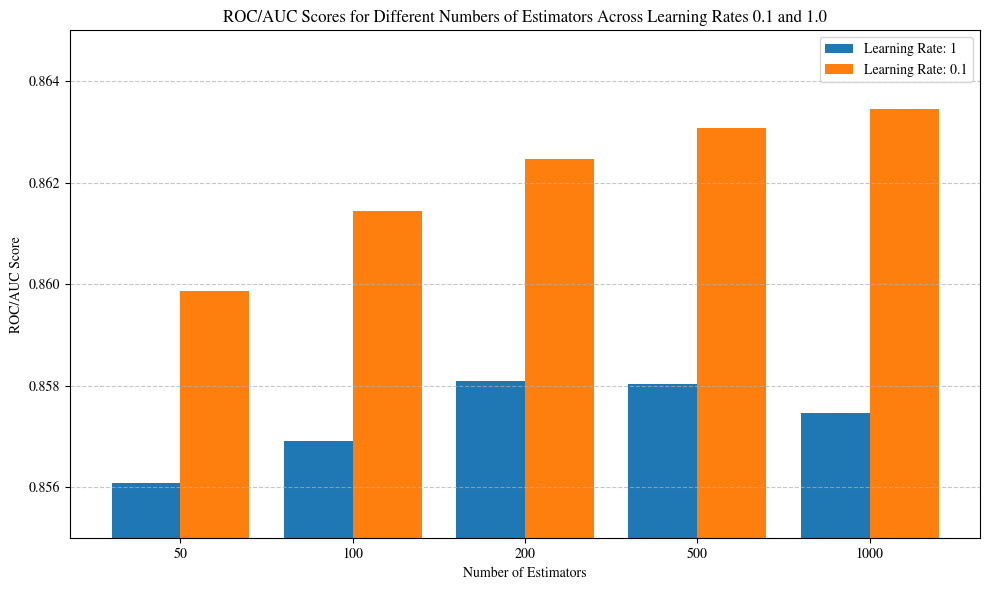

In [327]:
Ts = [50, 100, 200, 500, 1000]
auc_lr_1 = [0.85608, 0.85692, 0.8581, 0.85804, 0.85746]
auc_lr_0_1 = [0.85986, 0.86144, 0.86246, 0.86308, 0.86346]

idx = np.arange(len(Ts))

plt.figure(figsize=(10, 6))

bar_width = 0.4
bars1 = plt.bar(idx, auc_lr_1, bar_width, label='Learning Rate: 1')
bars2 = plt.bar(idx + bar_width, auc_lr_0_1, bar_width, label='Learning Rate: 0.1')

plt.xlabel('Number of Estimators')
plt.ylabel('ROC/AUC Score')
plt.title('ROC/AUC Scores for Different Numbers of Estimators Across Learning Rates 0.1 and 1.0')
plt.xticks(idx + bar_width / 2, Ts)
plt.legend()

plt.ylim(0.855, 0.865)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ROC/AUC is consistently higher with $\eta=0.1$.
With $\eta=1$, AUC peaks around 200 estimators before overfitting.
Whereas with $\eta=0.1$, AUC increases up to 1000 with diminishing improvement but no clear overfitting.
The lower rate results in more gradual learning and less sensitivity to outliers, greater stability, and reduced overfitting,
and training the 0.1 $\eta$ model beyond 1000 classifiers would likely further improve performance.
However, training cost contrains this, with Kaggle's 12 hour limit.
I use 50 estimators for remaining tuning.

### Weight update increase factor

In [299]:
import time
import numpy as np
import random

def train_adaboost_increase_multiple(args, X, y):
    increase_multiple = args['increase_multiple']
    _, _, _, val_metrics, _ = train_adaboost_k_fold(args, X, y, stratified=True)
    avg_val_metrics = avg_metrics(val_metrics)
    return increase_multiple, avg_val_metrics

def search_best_increase_multiple(args, increase_multiples, X, y, metric='roc_auc'):
    start_time = time.time()

    local_args = args.copy()
    local_args['silent'] = True

    best_score, best_result = 0, {}
    results = {}
    print(f"Searching for the best cross-validation {metric}...")

    for multiple in increase_multiples:
        current_args = local_args.copy()
        current_args['increase_multiple'] = multiple
        
        increase_multiple, avg_val_metrics = train_adaboost_increase_multiple(current_args, X, y)
        results[f'increase_multiple={increase_multiple}'] = avg_val_metrics

        score = avg_val_metrics[metric]

        print(f"increase_multiple: {increase_multiple}, score: {score}")

        if score > best_score:
            best_result = {'increase_multiple': increase_multiple, 'score': score}
            best_score = score

    elapsed_time = time.time() - start_time

    print(f"Search took {elapsed_time:.4f} seconds.")
    print(f"Best model was {best_result}")
    print("Best metrics:", results[f'increase_multiple={best_result['increase_multiple']}'])

    return best_result, results, elapsed_time

In [239]:
args['early_stopping'] = False
args['learning_rate'] = 0.1
args['N'] = 500000
X_strat, y_strat = sample_stratified(args, X, y)
X_strat, y_strat = encode_data(X_strat), encode_labels(y_strat)
args

{'N': 500000,
 'boost_labels': True,
 'base_dir': 'kaggle/data/',
 'T': 50,
 'visualise': False,
 'random_state': 123,
 'decision_tree': True,
 'es_tolerance': 0,
 'es_patience': 10,
 'max_depth': 5,
 'criterion': 'entropy',
 'early_stopping': False,
 'learning_rate': 0.1}

In [245]:
best_increase_multiple, increase_multiples, _ = search_best_increase_multiple(args, [1, 1.25, 1.5, 1.75, 2], X_strat, y_strat)

Searching for the best cross-validation roc_auc...
increase_multiple: 1, score: 0.86202
increase_multiple: 1.25, score: 0.8623
increase_multiple: 1.5, score: 0.86298
increase_multiple: 1.75, score: 0.8630800000000001
increase_multiple: 2, score: 0.86296
Search took 444.6145 seconds.
Best model was {'increase_multiple': 1.75, 'score': 0.8630800000000001}


KeyError: 'increase_multiple=1.7500'

Using an increase multiple of 1.75 slightly improved the AUC/ROC (from 0.862 to 0.863).

In [246]:
args['increase_multiple'] = 1.75

### Removing easy and difficult samples

I experiment with
removing samples by manually trialing a few possibilities.

In [251]:
args['remove_hard_every_m_rounds'] = 10
args['remove_easy_every_n_rounds'] = 10
args['easy_threshold'] = 0.8
args['hard_threshold'] = 0.4

args['remove_easy'] = True
args['remove_hard'] = False

_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 39.0564980506897 seconds.


0.8503999999999999

In [253]:
args['easy_threshold'] = 0.95
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 63.309053897857666 seconds.


0.85418

Removing easy samples does not appear to improve performance. Further tuning of removal timing could be explored, but removing easy samples may be redundant due to weight increase factor (1.75).

In [254]:
args['remove_easy'] = False
args['remove_hard'] = True
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 92.32012701034546 seconds.


0.8630799999999998

In [255]:
args['hard_threshold'] = 0.5
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 85.96533536911011 seconds.


0.8630799999999998

In [259]:
args['hard_threshold'] = 0.51
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 98.92392086982727 seconds.


0.86352

In [260]:
args['hard_threshold'] = 0.52
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 97.51685762405396 seconds.


0.8630800000000001

In [261]:
args['hard_threshold'] = 0.51
args['remove_hard_every_m_rounds'] = 20
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 97.93886733055115 seconds.


0.8634600000000001

In [262]:
args['hard_threshold'] = 0.50
args['remove_hard_every_m_rounds'] = 20
_, _, _, val_metrics, _ = train_adaboost_k_fold(args, X_strat, y_strat, stratified=True)
avg_metrics(val_metrics)['roc_auc']

Fold 1 complete.
Fold 2 complete.
Fold 3 complete.
Fold 4 complete.
Fold 5 complete.
Completed cross-validation in 97.51076173782349 seconds.


0.8630800000000001

Baseline ROC/AUC: 0.86308



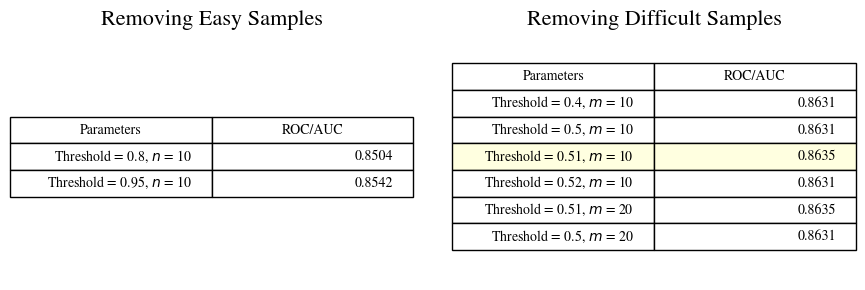

In [396]:
easy_data = {
    'Parameters': ['Threshold = 0.8, $n$ = 10', 'Threshold = 0.95, $n$ = 10'],
    'ROC/AUC': np.round([0.8503999999999999, 0.85418], 4)
}

hard_data = {
    'Parameters': ['Threshold = 0.4, $m$ = 10', 'Threshold = 0.5, $m$ = 10',
                    'Threshold = 0.51, $m$ = 10', 'Threshold = 0.52, $m$ = 10',
                    'Threshold = 0.51, $m$ = 20', 'Threshold = 0.5, $m$ = 20'],
    'ROC/AUC': np.round([0.8630799999999998, 0.8630799999999998, 0.86352, 
                  0.8630800000000001, 0.8634600000000001, 0.8630800000000001], 4)
}
easy_df = pd.DataFrame(easy_data)
hard_df = pd.DataFrame(hard_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,3))

ax1.axis('off')
easy_table = ax1.table(cellText=easy_df.values, colLabels=easy_df.columns, loc='center')
easy_table.scale(1.5, 1.5)
ax1.set_title('Removing Easy Samples', fontsize=16)

ax2.axis('off') 
hard_table = ax2.table(cellText=hard_df.values, colLabels=hard_df.columns, loc='center')
hard_table.scale(1.5, 1.5) 
ax2.set_title('Removing Difficult Samples', fontsize=16)

# Highlight best
max_hard = hard_df['ROC/AUC'].idxmax() + 1 # +1 for header
for col in range(2):
    hard_table[(max_hard, col)].set_facecolor('lightyellow')

plt.tight_layout()
print("Baseline ROC/AUC: 0.86308\n") # with 1.75 increase factor
plt.show()

Removing easy samples reduces ROC/AUC across thresholds, and is likely redundant given weight factor 1.75 which already emphasises misclassified samples.
Removing difficult samples slightly improves AUC or yields no change.
Persistently misclassified samples may be noise or outliers,
and removing them reduces overfitting.
However, these gains are negligible (fouth decimal) and
there are minimal differences between
parameters for removing hard samples, with threshold 0.51, rounds 10 giving a slightly higher AUC.

### Hyperparameters for final model

In summary:
- decision tree depth: 5
- decision tree criterion: entropy
- leraning rate: 0.1
- increase multiple: 1.75
- hard samples removed every 10 rounds with 0.51 threshold
- no removal of easy samples

## Kaggle Competition Submission

For the submission, I create a Kaggle notebook to train the final model on the full training set.
CV suggests performance improves beyond 1000 rounds,
but runtime is contrained by the 12 h limit.
With 620 rounds, the notebook took 11 h 25 m,
obtainining a Kaggle score of 0.87432.
Relavent cells are merged below.

In [6]:
args = {
    # Data
    'boost_labels': True,
    'base_dir':'/kaggle/input/playground-series-s4e7/',

    # Model - tuned locally
    'T': 620,  # based on 12-hour limit
    'decision_tree': True,
    'max_depth': 5,
    'criterion': 'entropy',
    'learning_rate': 0.1,
    'increase_multiple': 1.75,
    'remove_hard': True,
    'remove_hard_every_m_rounds': 10,
    'hard_threshold': 0.51,
    'remove_easy': False,
    'early_stopping': False,
    
    # Misc
    'random_state': 123
}

In [7]:
df_train = pd.read_csv(args['base_dir'] + 'train.csv')
X, y = split_response(df_train)
X, y = undersample_neg(args, X, y, adaboost_labels=False)
X, y = encode_data(X), encode_labels(y)
X_train, y_train = X[:-1000], y[:-1000]
X_val, y_val = X[-1000:], y[-1000:]

In [ ]:
start_time = time.time()
classifier, train_err, val_err = train_adaboost(args, X_train, y_train, X_val, y_val)
elapsed_time = time.time() - start_time

In [9]:
print(f'Training took {elapsed_time/3600:.3f} hours.')

Training took 11.103 hours.


In [10]:
def classify_test(ids, X_test, classifier):
    pred = classify_and_sum_votes_tree(X_test, classifier)
    prob = calculate_probabilities(pred).probabilities   
    classifications = pd.concat([df_test['id'], prob], axis=1)
    
    return classifications

In [11]:
joblib.dump(classifier, '/kaggle/working/classifier.pkl')
pd.DataFrame(train_err).to_csv('/kaggle/working/train_err.csv', index=False)
pd.DataFrame(val_err).to_csv('/kaggle/working/val_err.csv', index=False)

In [12]:
df_test = pd.read_csv(args['base_dir'] + 'test.csv') 
X_test = encode_data(df_test)
submit = classify_test(df_test['id'], X_test, classifier)
submit.to_csv('/kaggle/working/submission.csv', index=False)